# LIBRARY

In [593]:
"""%pip install scikit-plot -q
%pip install scipy -q"""

'%pip install scikit-plot -q\n%pip install scipy -q'

In [594]:
import numpy as np
import scipy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
#from scikitplot.metrics import plot_roc
#from scikitplot.metrics import plot_precision_recall
from sklearn.tree._tree import TREE_LEAF
from sklearn.tree import plot_tree, DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
import numpy as np
from sklearn.ensemble import RandomForestClassifier

/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [595]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    mean_squared_error,
    mean_absolute_error, 
    r2_score
)

# IMPORT CONTROL DATA SET 

In [596]:
file_path = "../1.DATASET/CMI_V2_CONTROL.csv"
df=pd.read_csv(file_path)
df

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,1,9,0,NaN,14.035590,48.00,46.0,936.656,70.0,NaN,...,1.0,15.4107,27.0552,64.0,0.0,0.0,90.666667,8.000000,18.204545,11.000000
1,3,9,0,71.0,18.292347,56.00,81.6,1131.430,97.0,6.0,...,2.0,26.4798,45.9966,45.0,0.0,1.0,79.000000,23.000000,18.204545,7.000000
2,5,13,1,50.0,22.279952,59.50,112.2,1330.970,73.0,5.0,...,2.0,35.3804,63.1265,56.0,0.0,1.0,74.000000,18.000000,17.200000,10.500000
3,6,10,0,NaN,19.660760,55.00,84.6,1135.860,83.0,NaN,...,2.0,26.1957,47.2211,40.0,3.0,0.0,136.333333,11.000000,16.840263,11.000000
4,7,10,1,65.0,16.861286,59.25,84.2,1180.040,90.0,5.0,...,2.0,28.7680,50.4767,55.0,2.0,0.0,86.000000,14.662915,11.850000,7.682875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852,3952,15,0,40.0,26.364710,70.50,186.4,1719.310,74.0,5.0,...,3.0,54.2027,91.4887,90.0,3.0,1.0,117.333333,23.714789,26.417470,8.527654
1853,3953,8,0,65.0,17.139810,52.50,67.2,1035.270,65.0,NaN,...,1.0,20.2645,36.7181,58.0,2.0,0.0,77.333333,10.568299,18.526452,9.000000
1854,3954,7,1,NaN,13.927006,48.50,46.6,966.287,75.0,5.0,...,1.0,18.0937,30.0453,67.0,0.0,1.0,78.333333,9.540221,18.909726,8.750000
1855,3955,13,0,60.0,16.362460,59.50,82.4,1206.880,70.0,NaN,...,1.0,29.7790,52.8320,50.0,1.0,1.0,82.000000,26.000000,18.950000,8.500000


In [597]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1857 entries, 0 to 1856
Data columns (total 32 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      1857 non-null   int64  
 1   Basic_Demos-Age                         1857 non-null   int64  
 2   Basic_Demos-Sex                         1857 non-null   int64  
 3   CGAS-CGAS_Score                         1679 non-null   float64
 4   Physical-BMI                            1857 non-null   float64
 5   Physical-Height                         1857 non-null   float64
 6   Physical-Weight                         1857 non-null   float64
 7   BIA-BIA_BMR                             1857 non-null   float64
 8   Physical-HeartRate                      1853 non-null   float64
 9   Fitness_Endurance-Max_Stage             1206 non-null   float64
 10  FGC-FGC_TL                              1708 non-null   floa

## distribution of sii in control dataset

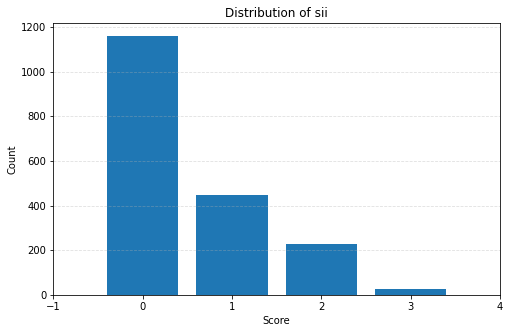

In [6]:
score_counts = df["sii"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(score_counts.index, score_counts.values)

plt.xlabel("Score")
plt.ylabel("Count")
plt.title("Distribution of sii")
plt.xlim(-1, 4)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

# Data Cleaning

## Removing useless variables

In [598]:
column2drop = ['id']
dfid=df.copy()
df.drop(column2drop, axis=1, inplace=True)

In [599]:
list1 = [4009, 4759,4837,4957,5518,5761,5780,5861,6844]

dfid[dfid.id.isin(list1) == True]

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL


In [600]:
df.head()

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,FGC-FGC_TL,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,9,0,NaN,14.035590,48.00,46.0,936.656,70.0,NaN,3.0,...,1.0,15.4107,27.0552,64.0,0.0,0.0,90.666667,8.000000,18.204545,11.000000
1,9,0,71.0,18.292347,56.00,81.6,1131.430,97.0,6.0,7.0,...,2.0,26.4798,45.9966,45.0,0.0,1.0,79.000000,23.000000,18.204545,7.000000
2,13,1,50.0,22.279952,59.50,112.2,1330.970,73.0,5.0,8.0,...,2.0,35.3804,63.1265,56.0,0.0,1.0,74.000000,18.000000,17.200000,10.500000
3,10,0,NaN,19.660760,55.00,84.6,1135.860,83.0,NaN,11.0,...,2.0,26.1957,47.2211,40.0,3.0,0.0,136.333333,11.000000,16.840263,11.000000
4,10,1,65.0,16.861286,59.25,84.2,1180.040,90.0,5.0,4.0,...,2.0,28.7680,50.4767,55.0,2.0,0.0,86.000000,14.662915,11.850000,7.682875


In [601]:
df.columns

Index(['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'BIA-BIA_BMR',
       'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMI', 'BIA-BIA_BMC',
       'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_ICW', 'BIA-BIA_FFMI',
       'BIA-BIA_FFM', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_LST',
       'BIA-BIA_Frame_num', 'BIA-BIA_SMM', 'BIA-BIA_TBW', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL'],
      dtype='object')

# TARGET VARIABLES

## TARGET VARIABLE Physical-Height

In [602]:
df_height = df[[ 'Physical-BMI','Physical-Height', 'Physical-Weight']].copy()


In [603]:
df_height.isnull().sum()

Physical-BMI       0
Physical-Height    0
Physical-Weight    0
dtype: int64

In [604]:
df_height[df_height['Physical-Height']==0]

,Physical-BMI,Physical-Height,Physical-Weight


### Partitioning

In [605]:
attributes = [col for col in df_height.columns if col != 'Physical-Height']
X = df_height[attributes].values
y = np.array(df_height['Physical-Height'])

In [606]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [607]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 2) (465, 2) (1392,) (465,)


In [608]:
df_height.shape

(1857, 3)

### Randomized Search

In [609]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [610]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_height = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_height = random_search.best_estimator_

In [611]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 23, 'criterion': 'squared_error'} -1.4494669837392782


In [612]:
dt_reg_height = random_search.best_estimator_
dt_reg_height.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=23, min_samples_leaf=5, min_samples_split=0.002)

In [613]:
y_pred = dt_reg_height.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 1.0631
MAE  : 0.7167
MSE  : 1.1301
R²   : 0.9785


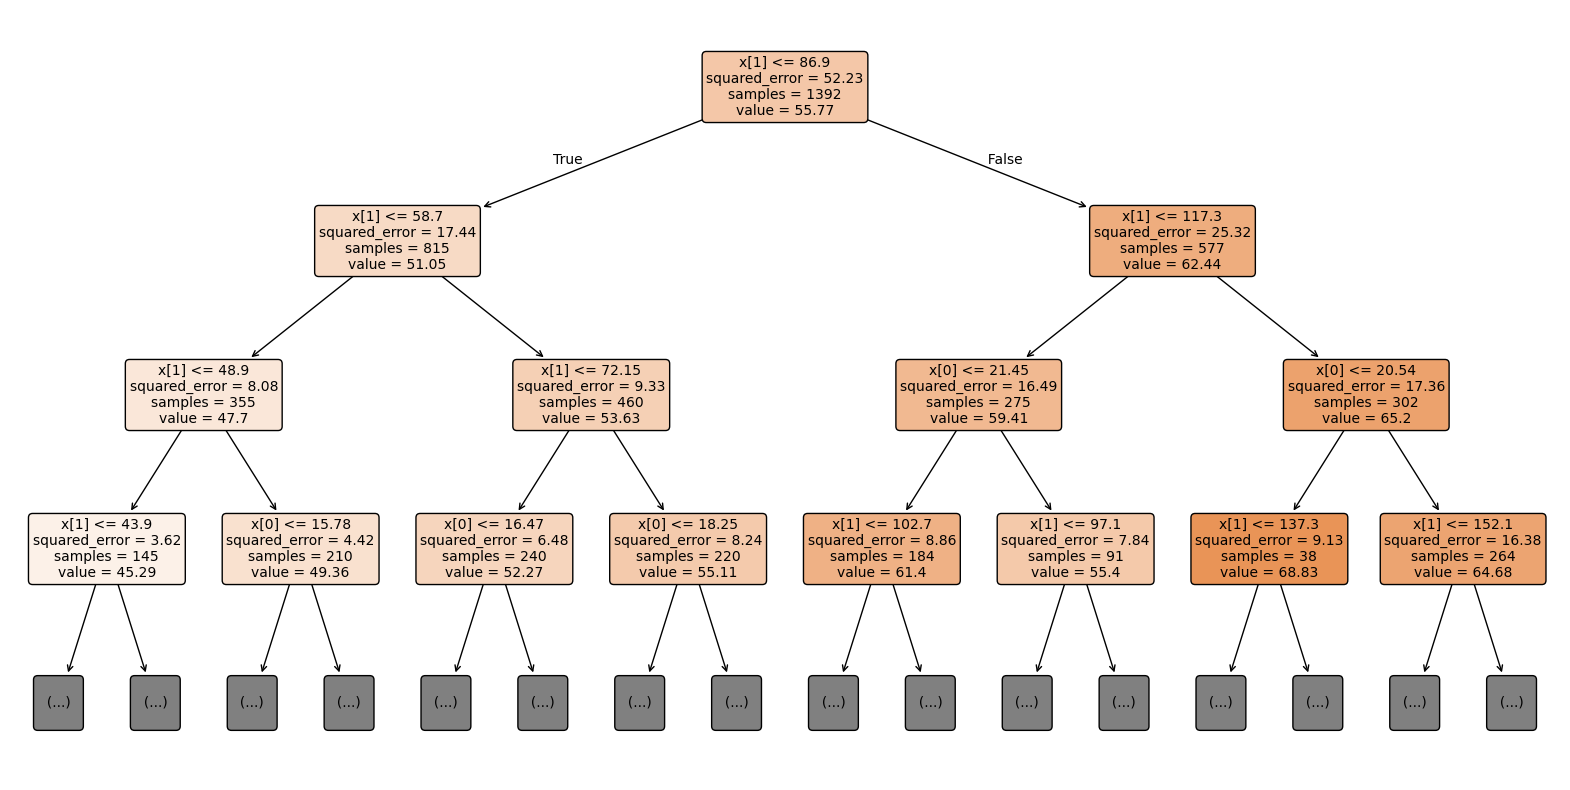

In [614]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_height,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
  77 | 41.5000 |   48.3333 | 6.8333
 311 | 49.0000 |   55.5071 | 6.5071
  24 | 77.5000 |   71.7000 | 5.8000
 366 | 70.5000 |   66.7000 | 3.8000
 235 | 70.0000 |   73.6786 | 3.6786
 272 | 70.0000 |   73.6786 | 3.6786
  99 | 64.0000 |   60.8000 | 3.2000
  44 | 70.5000 |   67.4000 | 3.1000
 415 | 70.5000 |   67.4000 | 3.1000
 210 | 50.0000 |   52.8600 | 2.8600


C:\Users\paula\AppData\Local\Temp\ipykernel_26128\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


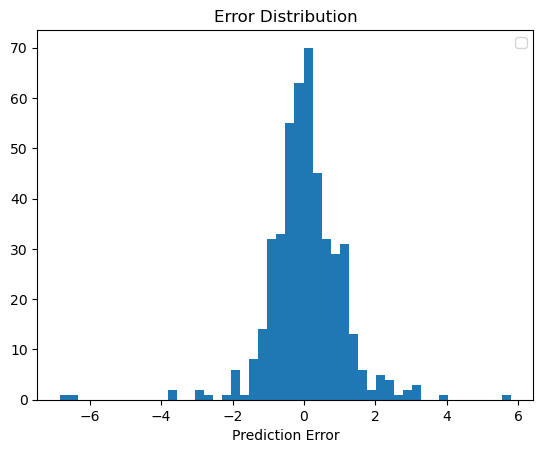

In [615]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [616]:
zipped = zip(attributes, dt_reg_height.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Physical-Weight 0.8721324010059177
Physical-BMI 0.12786759899408234


## TARGET VARIABLE BIA-BIA_TBW

In [617]:
df_BIA_TBW = dfid[['id','BIA-BIA_ECW', 'BIA-BIA_ICW','BIA-BIA_TBW','Physical-Weight']].copy()


In [618]:
df_BIA_TBW[(df_BIA_TBW['BIA-BIA_TBW']==0) |(df_BIA_TBW['BIA-BIA_TBW'].isna()) | (df_BIA_TBW['BIA-BIA_TBW']==44.987)| (df_BIA_TBW['BIA-BIA_TBW']>=df_BIA_TBW['Physical-Weight'])]

,id,BIA-BIA_ECW,BIA-BIA_ICW,BIA-BIA_TBW,Physical-Weight
1162,2492,15.9280,28.8558,44.987,68.8
1275,2726,18.5764,26.4106,44.987,84.0


In [619]:
list1 = [2492, 2726]

df_BIA_TBW=df_BIA_TBW[df_BIA_TBW.id.isin(list1) == False]

In [620]:
df_BIA_TBW

,id,BIA-BIA_ECW,BIA-BIA_ICW,BIA-BIA_TBW,Physical-Weight
0,1,6.01993,21.0352,27.0552,46.0
1,3,15.59250,30.4041,45.9966,81.6
2,5,30.21240,32.9141,63.1265,112.2
3,6,16.32750,30.8936,47.2211,84.6
4,7,21.94000,28.5367,50.4767,84.2
...,...,...,...,...,...
1852,3952,39.01240,52.4763,91.4887,186.4
1853,3953,11.00630,25.7118,36.7181,67.2
1854,3954,9.98802,20.0572,30.0453,46.6
1855,3955,19.46110,33.3709,52.8320,82.4


In [621]:
df_BIA_TBW=df_BIA_TBW.drop(columns = ['id','Physical-Weight'])

In [622]:
df_BIA_TBW

,BIA-BIA_ECW,BIA-BIA_ICW,BIA-BIA_TBW
0,6.01993,21.0352,27.0552
1,15.59250,30.4041,45.9966
2,30.21240,32.9141,63.1265
3,16.32750,30.8936,47.2211
4,21.94000,28.5367,50.4767
...,...,...,...
1852,39.01240,52.4763,91.4887
1853,11.00630,25.7118,36.7181
1854,9.98802,20.0572,30.0453
1855,19.46110,33.3709,52.8320


In [623]:
df_BIA_TBW.isnull().sum()

BIA-BIA_ECW    0
BIA-BIA_ICW    0
BIA-BIA_TBW    0
dtype: int64

In [624]:
df_BIA_TBW[df_BIA_TBW['BIA-BIA_TBW']==0]

,BIA-BIA_ECW,BIA-BIA_ICW,BIA-BIA_TBW


### Partitioning

In [625]:
attributes = [col for col in df_BIA_TBW.columns if col != 'BIA-BIA_TBW']
X = df_BIA_TBW[attributes].values
y = np.array(df_BIA_TBW['BIA-BIA_TBW'])

In [626]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [627]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1391, 2) (464, 2) (1391,) (464,)


In [628]:
df_BIA_TBW.shape

(1855, 3)

### Randomized Search

In [629]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [630]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_TBW = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_TBW = random_search.best_estimator_

In [631]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.001, 'min_samples_leaf': 5, 'max_depth': 31, 'criterion': 'absolute_error'} -1.885067290355477


In [632]:
dt_reg_TBW = random_search.best_estimator_
dt_reg_TBW.fit(X_train, y_train)

DecisionTreeRegressor(criterion='absolute_error', max_depth=31,
                      min_samples_leaf=5, min_samples_split=0.001)

In [633]:
y_pred = dt_reg_TBW.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 1.1841
MAE  : 0.6325
MSE  : 1.4020
R²   : 0.9960


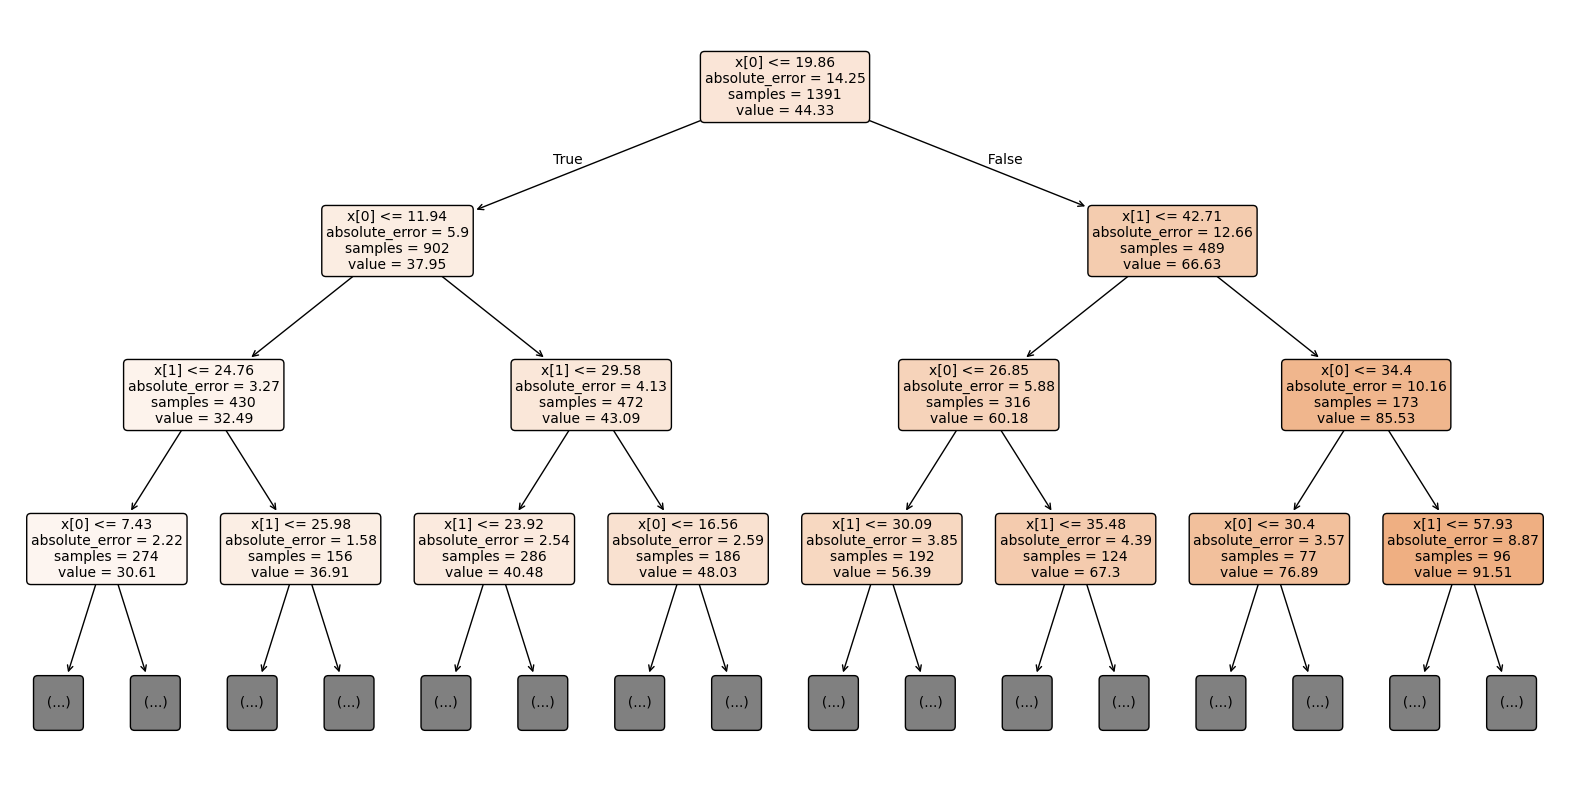

In [634]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_TBW,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 176 | 143.2380 |  132.0550 | 11.1830
 201 | 123.5600 |  132.0550 | 8.4950
  56 | 125.9560 |  118.0220 | 7.9340
 271 | 113.2760 |  108.2485 | 5.0275
 270 | 112.9330 |  108.2485 | 4.6845
 351 | 74.7493 |   79.2283 | 4.4790
 244 | 51.0086 |   46.5631 | 4.4455
  95 | 22.8800 |   26.9029 | 4.0229
 449 | 99.4712 |  103.2245 | 3.7533
 290 | 94.2103 |   97.5550 | 3.3447


C:\Users\paula\AppData\Local\Temp\ipykernel_26128\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


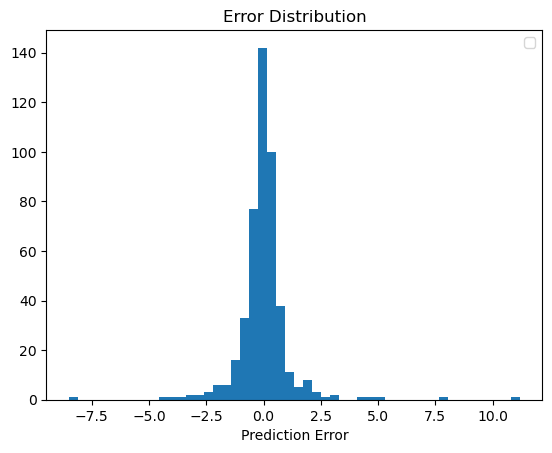

In [635]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [636]:
zipped = zip(attributes, dt_reg_TBW.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_ECW 0.6787980015424947
BIA-BIA_ICW 0.32120199845750524


## TARGET VARIABLE BIA-BIA_Fat

In [637]:
df_BIA_Fat = dfid[['id','Physical-Weight', 
                'Physical-Height','BIA-BIA_FMI',
                'BIA-BIA_Fat'                          
]].copy()



In [638]:
df_BIA_Fat[(df_BIA_Fat['BIA-BIA_Fat']<=0) |(df_BIA_Fat['BIA-BIA_Fat'].isna()) | (df_BIA_Fat['BIA-BIA_Fat']==16.1746)| (df_BIA_Fat['BIA-BIA_Fat']>=df_BIA_Fat['Physical-Weight'])]

,id,Physical-Weight,Physical-Height,BIA-BIA_FMI,BIA-BIA_Fat
498,1089,83.8,57.5,3.43954,16.1746
1162,2492,68.8,53.0,3.69863,16.1746


In [639]:
list1 = [1089, 2492]

df_BIA_Fat=df_BIA_Fat[df_BIA_Fat.id.isin(list1) == False]
df_BIA_Fat=df_BIA_Fat.drop(columns = ['id'])
df_BIA_Fat


,Physical-Weight,Physical-Height,BIA-BIA_FMI,BIA-BIA_Fat
0,46.0,48.00,1.211720,3.97085
1,81.6,56.00,4.220330,18.82430
2,112.2,59.50,13.498800,67.97150
3,84.6,55.00,4.962910,21.35300
4,84.2,59.25,3.253950,16.24740
...,...,...,...,...
1852,186.4,70.50,8.630020,61.00800
1853,67.2,52.50,3.741300,14.66690
1854,46.6,48.50,0.414263,1.41470
1855,82.4,59.50,2.301380,11.58830


In [640]:
df_BIA_Fat.isnull().sum()

Physical-Weight    0
Physical-Height    0
BIA-BIA_FMI        0
BIA-BIA_Fat        0
dtype: int64

### Partitioning

In [641]:
attributes = [col for col in df_BIA_Fat.columns if col != 'BIA-BIA_Fat']
X = df_BIA_Fat[attributes].values
y = np.array(df_BIA_Fat['BIA-BIA_Fat'])

In [642]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [643]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1391, 3) (464, 3) (1391,) (464,)


In [644]:
df_BIA_Fat.shape

(1855, 4)

### Randomized Search

In [645]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [646]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_FAT = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_FAT = random_search.best_estimator_

In [647]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.001, 'min_samples_leaf': 5, 'max_depth': 46, 'criterion': 'friedman_mse'} -8.025518433995794


In [648]:
dt_reg_FAT = random_search.best_estimator_
dt_reg_FAT.fit(X_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=46,
                      min_samples_leaf=5, min_samples_split=0.001)

In [649]:
y_pred = dt_reg_FAT.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 2.4844
MAE  : 1.2904
MSE  : 6.1721
R²   : 0.9855


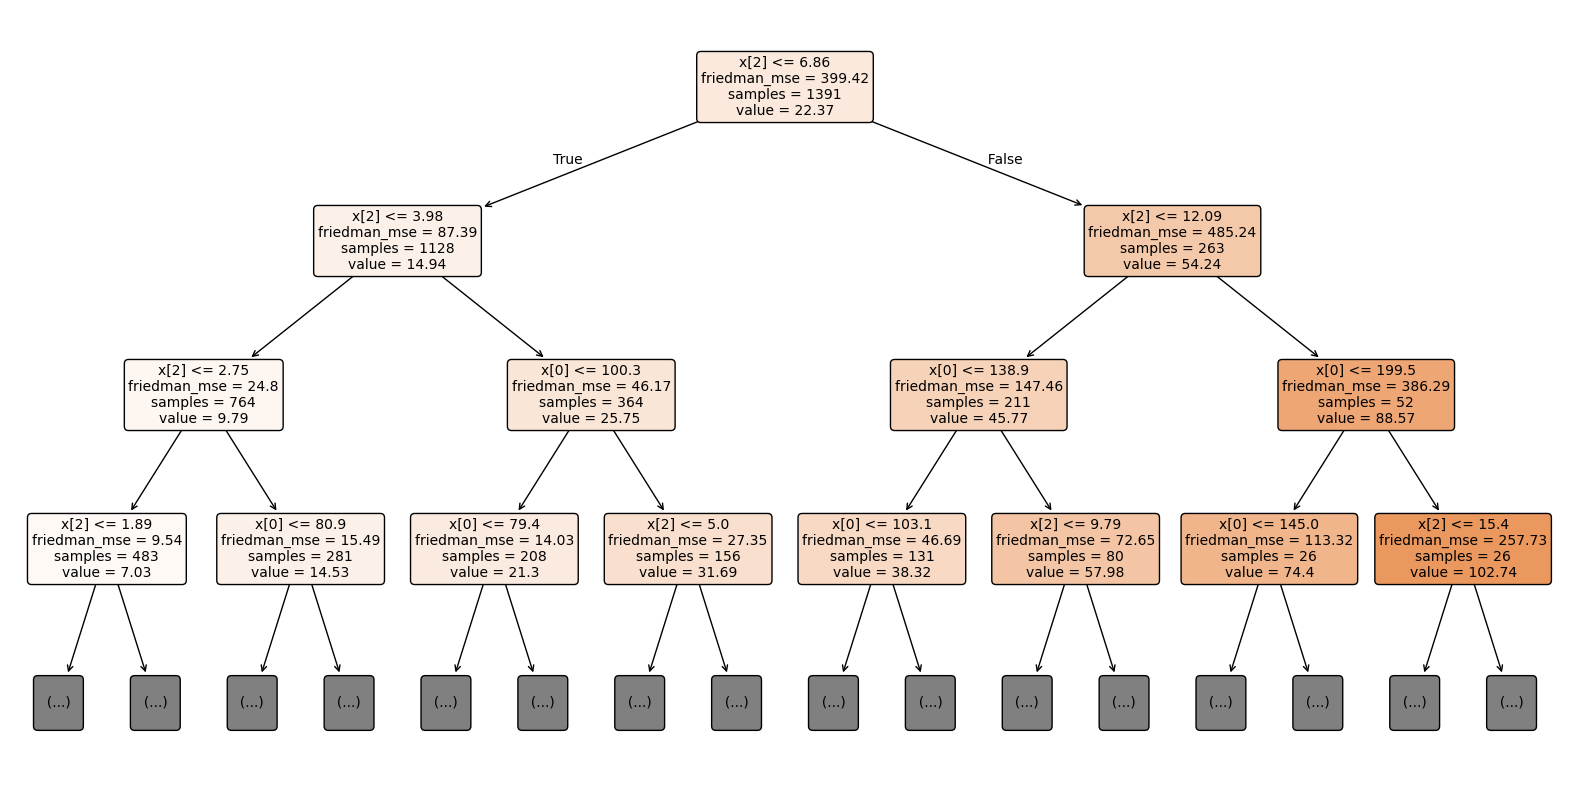

In [650]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_FAT,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 398 | 33.8424 |   59.9996 | 26.1572
 197 | 108.5070 |  125.7332 | 17.2262
 279 | 79.5701 |   63.5248 | 16.0453
 341 | 75.3255 |   63.5248 | 11.8007
 172 | 83.5875 |   73.4805 | 10.1070
  74 | 75.4429 |   84.4816 | 9.0387
 373 | 116.9160 |  125.7332 | 8.8172
 187 | 92.7019 |   84.9050 | 7.7969
 125 | 58.5514 |   52.1200 | 6.4314
 248 | 65.2936 |   71.2862 | 5.9926


C:\Users\paula\AppData\Local\Temp\ipykernel_26128\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


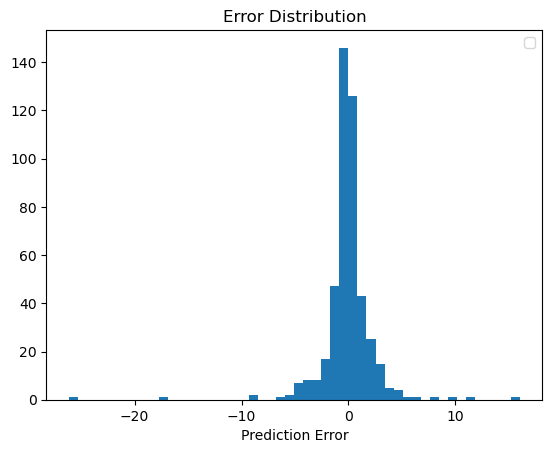

In [651]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [652]:
zipped = zip(attributes, dt_reg_FAT.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_FMI 0.8938696301490014
Physical-Weight 0.10213710429556494
Physical-Height 0.00399326555543367


## TARGET VARIABLE BIA-BIA_FFM

In [9]:
df_BIA_FatFree = dfid[['id','Physical-Weight', 
                'Physical-Height',
                #'BIA-BIA_Fat',
                'BIA-BIA_FFMI',
                'BIA-BIA_FFM'                         
]].copy()



In [10]:
df_BIA_FatFree[(df_BIA_FatFree['BIA-BIA_FFM'].isna()) | (df_BIA_FatFree['BIA-BIA_FFM']==61.0662)| (df_BIA_FatFree['BIA-BIA_FFM']>=df_BIA_FatFree['Physical-Weight'])]

,id,Physical-Weight,Physical-Height,BIA-BIA_FFMI,BIA-BIA_FFM
702,1535,81.4,54.0,14.7237,61.0662
1162,2492,68.8,53.0,NaN,61.0662


In [11]:
list1 = [1535, 2492]

df_BIA_FatFree=df_BIA_FatFree[df_BIA_FatFree.id.isin(list1) == False]
df_BIA_FatFree=df_BIA_FatFree.drop(columns = ['id'])
df_BIA_FatFree


,Physical-Weight,Physical-Height,BIA-BIA_FFMI,BIA-BIA_FFM
0,46.0,48.00,12.8254,42.0291
1,81.6,56.00,14.0740,62.7757
2,112.2,59.50,16.6877,84.0285
3,84.6,55.00,14.7000,63.2470
4,84.2,59.25,13.6092,67.9527
...,...,...,...,...
1852,186.4,70.50,17.7376,125.3920
1853,67.2,52.50,13.4004,52.5331
1854,46.6,48.50,13.2315,45.1853
1855,82.4,59.50,14.0629,70.8117


In [12]:
df_BIA_FatFree.isnull().sum()

Physical-Weight    0
Physical-Height    0
BIA-BIA_FFMI       0
BIA-BIA_FFM        0
dtype: int64

### Partitioning

In [13]:
attributes = [col for col in df_BIA_FatFree.columns if col != 'BIA-BIA_FFM']
X = df_BIA_FatFree[attributes].values
y = np.array(df_BIA_FatFree['BIA-BIA_FFM'])

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [15]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1391, 3) (464, 3) (1391,) (464,)


In [16]:
df_BIA_FatFree.shape

(1855, 4)

### Randomized Search

In [17]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [18]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_FATFREE = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_FATFREE = random_search.best_estimator_

/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (

In [19]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.001, 'min_samples_leaf': 5, 'max_depth': 38, 'criterion': 'friedman_mse'} -16.861666702203017


In [20]:
dt_reg_FATFREE = random_search.best_estimator_
dt_reg_FATFREE.fit(X_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=38,
                      min_samples_leaf=5, min_samples_split=0.001)

In [21]:
y_pred = dt_reg_FATFREE.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 3.8968
MAE  : 2.0828
MSE  : 15.1850
R²   : 0.9771


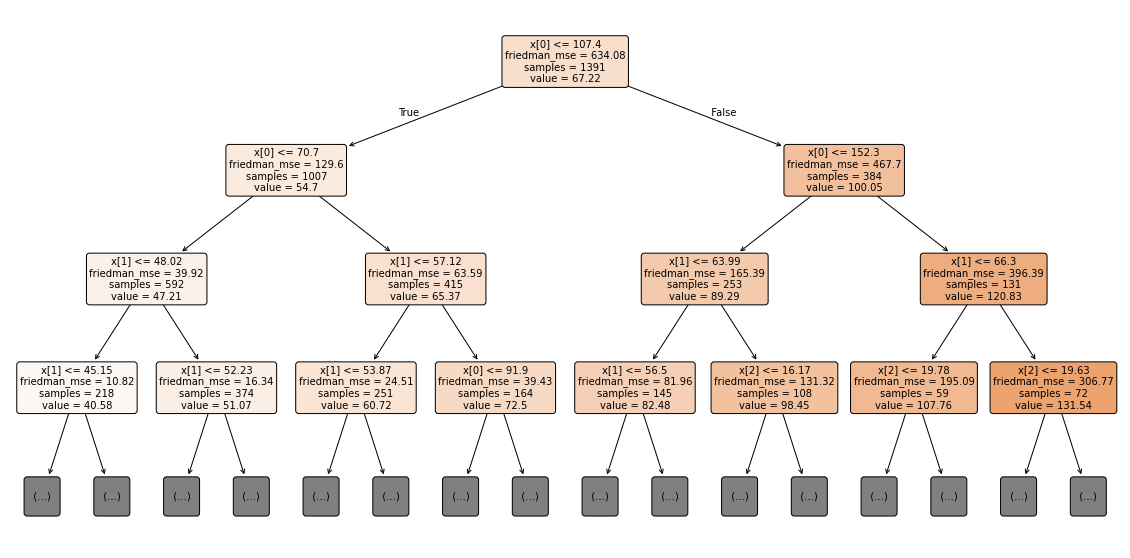

In [22]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_FATFREE,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 431 | 130.0340 |  167.7309 | 37.6969
 201 | 165.8170 |  135.7461 | 30.0709
 197 | 193.8930 |  167.7309 | 26.1621
 415 | 186.2920 |  167.7309 | 18.5611
  32 | 105.6390 |  120.1001 | 14.4611
  45 | 106.3830 |   93.5872 | 12.7958
 361 | 180.3900 |  167.7309 | 12.6591
  74 | 81.1571 |   93.5872 | 12.4301
 285 | 108.1540 |  120.1001 | 11.9461
 458 | 108.6670 |   97.5243 | 11.1427


/var/folders/z_/h8pm6bx50mngk0pbk5p07btc0000gn/T/ipykernel_2088/1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


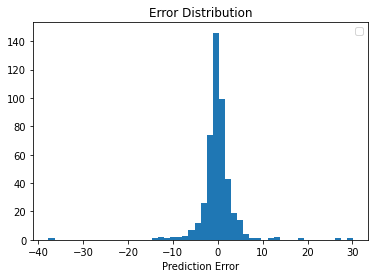

In [23]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [24]:
zipped = zip(attributes, dt_reg_FATFREE.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Physical-Weight 0.855534939632348
Physical-Height 0.10033503859362443
BIA-BIA_FFMI 0.044130021774027736


## TARGET VARIABLE BIA-BIA_DEE

In [653]:
df_BIA_DEE = dfid[['id',
    'BIA-BIA_DEE',
    'BIA-BIA_BMR',                  
    'BIA-BIA_Activity_Level_num',   
    'Basic_Demos-Sex',
    'BIA-BIA_TBW'         
]]



In [654]:
df_BIA_DEE[(df_BIA_DEE['BIA-BIA_DEE']==0) |(df_BIA_DEE['BIA-BIA_DEE'].isna()) | (df_BIA_DEE['BIA-BIA_DEE']==1863.98)]

,id,BIA-BIA_DEE,BIA-BIA_BMR,BIA-BIA_Activity_Level_num,Basic_Demos-Sex,BIA-BIA_TBW
336,736,1863.98,1164.99,2.0,0,50.8638
1162,2492,NaN,1062.40,3.0,1,44.9870


In [655]:
list1 = [736, 2492]

df_BIA_DEE=df_BIA_DEE[df_BIA_DEE.id.isin(list1) == False]
df_BIA_DEE=df_BIA_DEE.drop(columns = ['id'])
df_BIA_DEE

,BIA-BIA_DEE,BIA-BIA_BMR,BIA-BIA_Activity_Level_num,Basic_Demos-Sex,BIA-BIA_TBW
0,1498.65,936.656,2.0,0,27.0552
1,1923.44,1131.430,3.0,0,45.9966
2,1996.45,1330.970,2.0,1,63.1265
3,1817.38,1135.860,2.0,0,47.2211
4,1888.06,1180.040,3.0,1,50.4767
...,...,...,...,...,...
1852,2922.82,1719.310,3.0,0,91.4887
1853,1759.96,1035.270,3.0,0,36.7181
1854,1256.17,966.287,1.0,1,30.0453
1855,2051.70,1206.880,3.0,0,52.8320


In [656]:
df_BIA_DEE.isnull().sum()

BIA-BIA_DEE                   0
BIA-BIA_BMR                   0
BIA-BIA_Activity_Level_num    0
Basic_Demos-Sex               0
BIA-BIA_TBW                   0
dtype: int64

### Partitioning

In [657]:
attributes = [col for col in df_BIA_DEE.columns if col != 'BIA-BIA_DEE']
X = df_BIA_DEE[attributes].values
y = np.array(df_BIA_DEE['BIA-BIA_DEE'])

In [658]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [659]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1391, 4) (464, 4) (1391,) (464,)


In [660]:
df_BIA_DEE.shape

(1855, 5)

### Randomized Search

In [661]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [662]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_DEE = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_DEE = random_search.best_estimator_

In [663]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 36, 'criterion': 'absolute_error'} -6688.975001447616


In [664]:
dt_reg_DEE = random_search.best_estimator_
dt_reg_DEE.fit(X_train, y_train)

DecisionTreeRegressor(criterion='absolute_error', max_depth=36,
                      min_samples_leaf=5, min_samples_split=0.002)

In [665]:
y_pred = dt_reg_DEE.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 89.4776
MAE  : 34.0762
MSE  : 8006.2476
R²   : 0.9704


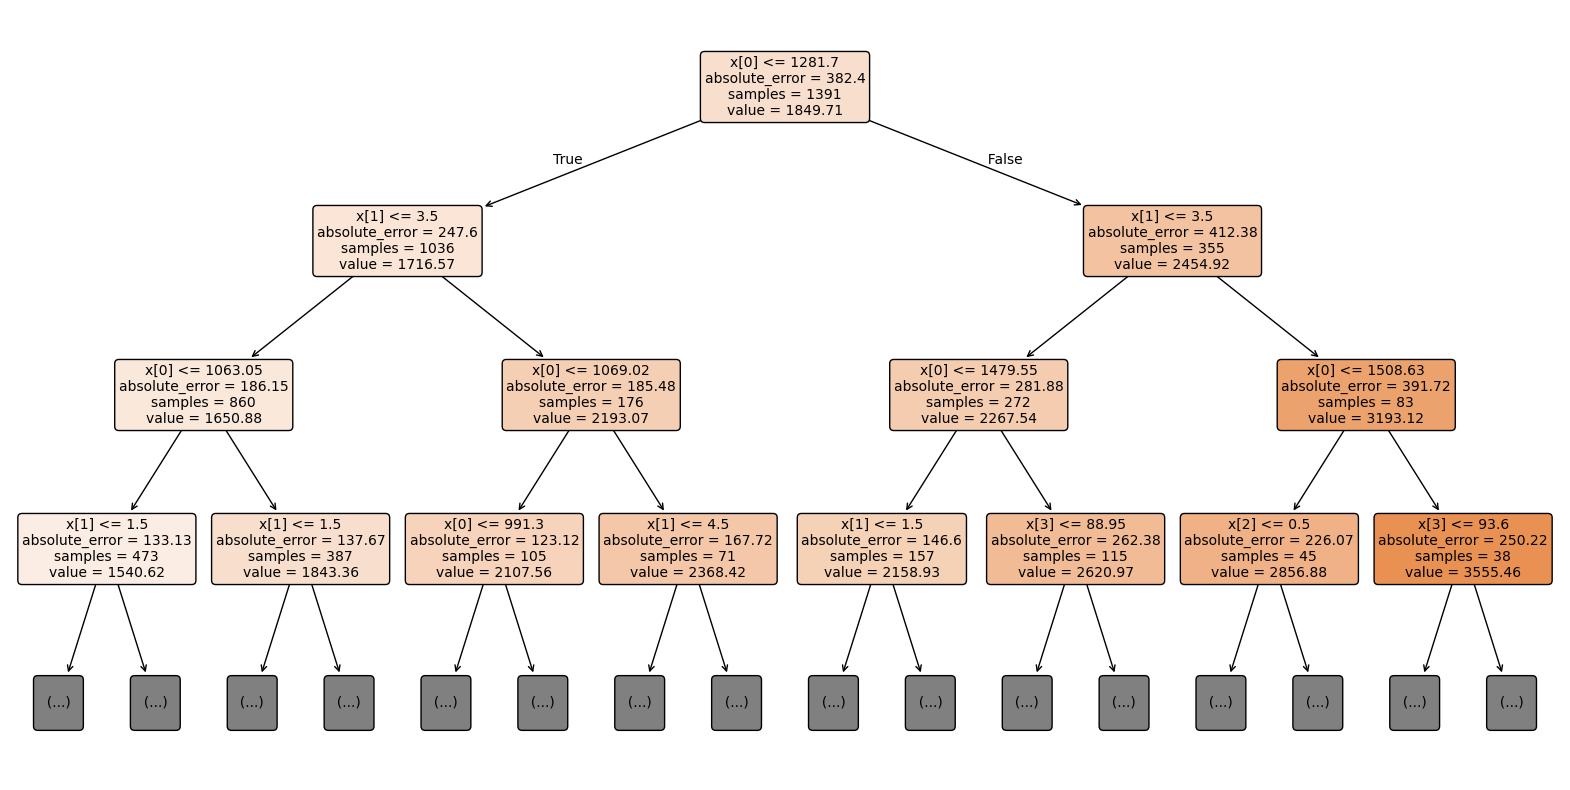

In [666]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_DEE,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
  48 | 2654.6100 | 3516.9850 | 862.3750
 279 | 2818.9700 | 3516.9850 | 698.0150
 361 | 2906.3600 | 3516.9850 | 610.6250
 345 | 4517.1300 | 3915.7350 | 601.3950
 434 | 3724.5800 | 3241.3200 | 483.2600
 197 | 3071.1600 | 3516.9850 | 445.8250
 401 | 3189.5500 | 2823.8800 | 365.6700
   8 | 2990.8500 | 3335.9700 | 345.1200
 265 | 3167.9400 | 2823.8800 | 344.0600
 341 | 3409.3500 | 3136.7300 | 272.6200


C:\Users\paula\AppData\Local\Temp\ipykernel_26128\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


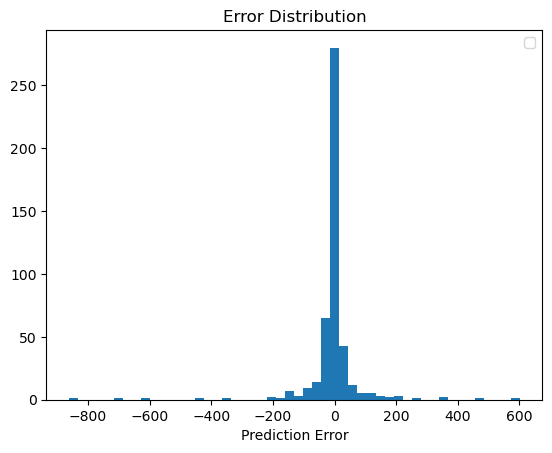

In [667]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [668]:
zipped = zip(attributes, dt_reg_DEE.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_BMR 0.566243909556796
BIA-BIA_Activity_Level_num 0.3451020315608681
Basic_Demos-Sex 0.044363429143818287
BIA-BIA_TBW 0.04429062973851764


## TARGET VARIABLE BIA-BIA_BMC

In [669]:
df_BIA_BMC = dfid[['id',
'BIA-BIA_LST' ,
'BIA-BIA_ICW',
'BIA-BIA_BMR' ,
'BIA-BIA_BMC'
]]





In [670]:
df_BIA_BMC[(df_BIA_BMC['BIA-BIA_BMC']<=0) |(df_BIA_BMC['BIA-BIA_BMC'].isna()) | (df_BIA_BMC['BIA-BIA_BMC']==3.92272)]

,id,BIA-BIA_LST,BIA-BIA_ICW,BIA-BIA_BMR,BIA-BIA_BMC
1162,2492,56.9964,28.8558,1062.40,3.92272
1848,3945,57.3004,29.6535,1116.86,3.92272


In [671]:
list1 = [3945, 2492]

df_BIA_BMC=df_BIA_BMC[df_BIA_BMC.id.isin(list1) == False]
df_BIA_BMC=df_BIA_BMC.drop(columns = ['id'])
df_BIA_BMC

,BIA-BIA_LST,BIA-BIA_ICW,BIA-BIA_BMR,BIA-BIA_BMC
0,39.4497,21.0352,936.656,2.57949
1,58.9338,30.4041,1131.430,3.84191
2,79.6982,32.9141,1330.970,4.33036
3,59.4643,30.8936,1135.860,3.78271
4,63.8954,28.5367,1180.040,4.05726
...,...,...,...,...
1852,118.4330,52.4763,1719.310,6.95881
1853,49.3301,25.7118,1035.270,3.20303
1854,42.8185,20.0572,966.287,2.36680
1855,66.2889,33.3709,1206.880,4.52277


In [672]:
df_BIA_BMC.isnull().sum()

BIA-BIA_LST    0
BIA-BIA_ICW    0
BIA-BIA_BMR    0
BIA-BIA_BMC    0
dtype: int64

### Partitioning

In [673]:
attributes = [col for col in df_BIA_BMC.columns if col != 'BIA-BIA_BMC']
X = df_BIA_BMC[attributes].values
y = np.array(df_BIA_BMC['BIA-BIA_BMC'])

In [674]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [675]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1391, 3) (464, 3) (1391,) (464,)


In [676]:
df_BIA_BMC.shape

(1855, 4)

### Randomized Search

In [677]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [678]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_BMC = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_BMC = random_search.best_estimator_

In [679]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 22, 'criterion': 'friedman_mse'} -1.8434359630802226


In [680]:
dt_reg_BMC = random_search.best_estimator_
dt_reg_BMC.fit(X_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=22,
                      min_samples_leaf=5, min_samples_split=0.002)

In [681]:
y_pred = dt_reg_BMC.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 1.2303
MAE  : 0.6339
MSE  : 1.5136
R²   : 0.7382


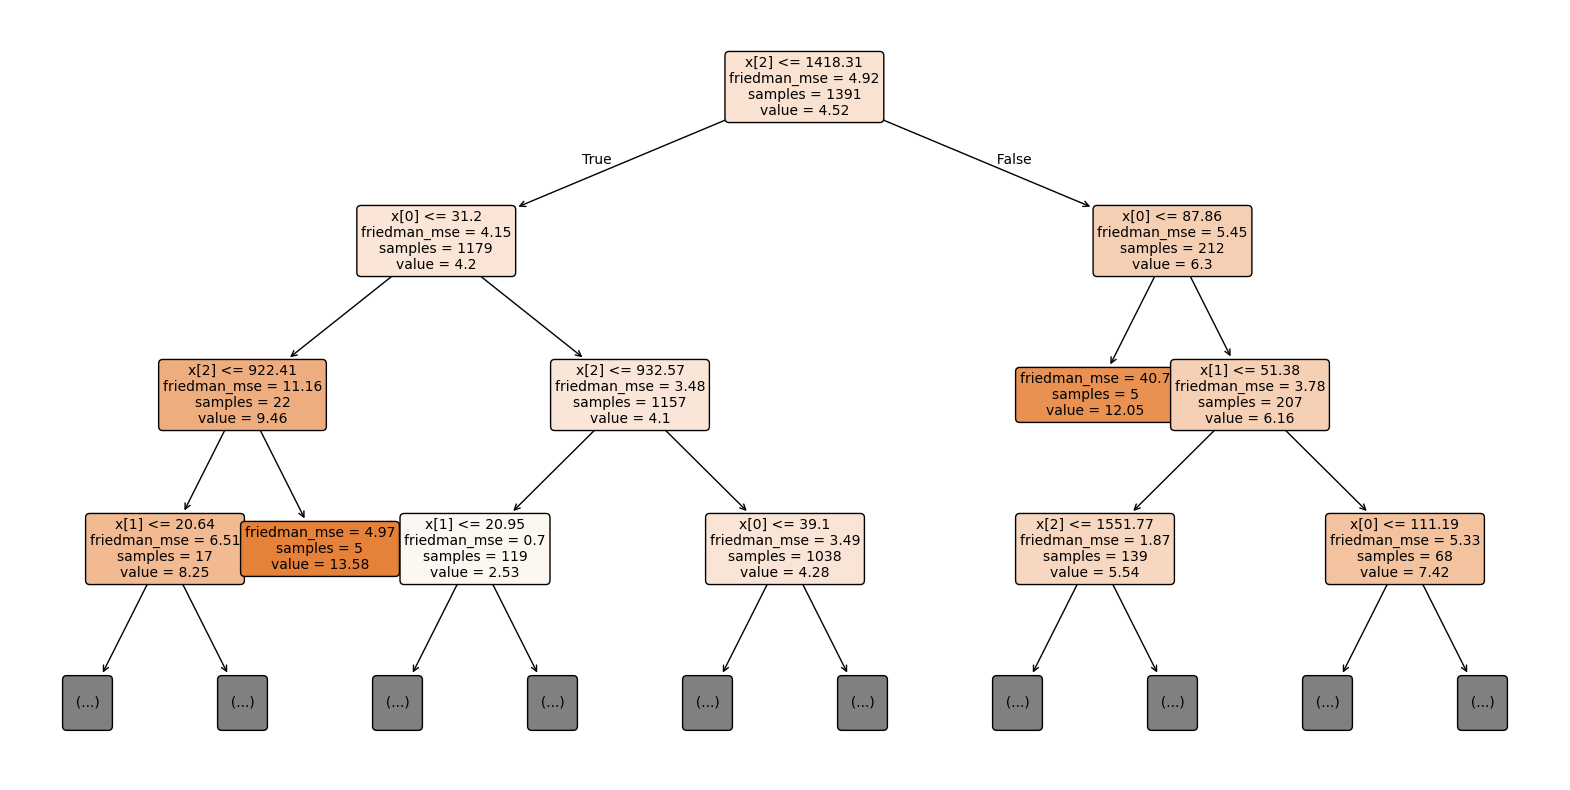

In [682]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_BMC,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 174 | 15.1353 |    5.2342 | 9.9011
  26 | 22.4353 |   13.5825 | 8.8528
 178 | 11.0942 |    4.8319 | 6.2623
  85 | 16.3969 |   10.6219 | 5.7750
  67 |  0.4167 |    5.7338 | 5.3170
  93 |  0.6163 |    5.5652 | 4.9489
 227 | 10.6158 |    6.2150 | 4.4008
  65 |  5.9782 |   10.2196 | 4.2414
 124 | 11.5591 |    7.4470 | 4.1121
 122 |  6.1366 |   10.2196 | 4.0830


C:\Users\paula\AppData\Local\Temp\ipykernel_26128\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


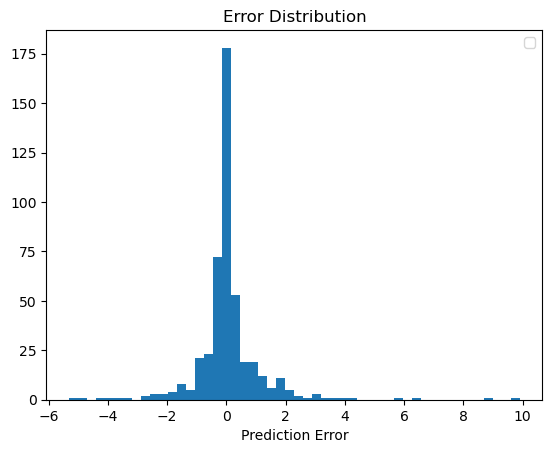

In [683]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [684]:
zipped = zip(attributes, dt_reg_BMC.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_LST 0.5159040415617107
BIA-BIA_BMR 0.40245676211063797
BIA-BIA_ICW 0.08163919632765142


## TARGET VARIABLE BIA-BIA_SMM

In [685]:
df_BIA_SMM = dfid[['id',
'BIA-BIA_LST',
'BIA-BIA_ICW',
'BIA-BIA_FFM',
'BIA-BIA_SMM',
'Physical-Weight'
]]






In [686]:
df_BIA_SMM[(df_BIA_SMM['BIA-BIA_SMM']==0) |(df_BIA_SMM['BIA-BIA_SMM'].isna()) | (df_BIA_SMM['BIA-BIA_SMM']==27.4151)| (df_BIA_SMM['BIA-BIA_SMM']>=df_BIA_SMM['BIA-BIA_FFM'])| (df_BIA_SMM['BIA-BIA_SMM']>=df_BIA_SMM['Physical-Weight'])]

,id,BIA-BIA_LST,BIA-BIA_ICW,BIA-BIA_FFM,BIA-BIA_SMM,Physical-Weight
769,1659,54.8441,26.6444,61.3799,27.4151,86.4
1162,2492,56.9964,28.8558,61.0662,27.4151,68.8


In [687]:
list1 = [1659, 2492]

df_BIA_SMM=df_BIA_SMM[df_BIA_SMM.id.isin(list1) == False]
df_BIA_SMM=df_BIA_SMM.drop(columns = ['id','Physical-Weight'])
df_BIA_SMM

,BIA-BIA_LST,BIA-BIA_ICW,BIA-BIA_FFM,BIA-BIA_SMM
0,39.4497,21.0352,42.0291,15.4107
1,58.9338,30.4041,62.7757,26.4798
2,79.6982,32.9141,84.0285,35.3804
3,59.4643,30.8936,63.2470,26.1957
4,63.8954,28.5367,67.9527,28.7680
...,...,...,...,...
1852,118.4330,52.4763,125.3920,54.2027
1853,49.3301,25.7118,52.5331,20.2645
1854,42.8185,20.0572,45.1853,18.0937
1855,66.2889,33.3709,70.8117,29.7790


In [688]:
df_BIA_SMM.isnull().sum()

BIA-BIA_LST    0
BIA-BIA_ICW    0
BIA-BIA_FFM    0
BIA-BIA_SMM    0
dtype: int64

### Partitioning

In [689]:
attributes = [col for col in df_BIA_SMM.columns if col != 'BIA-BIA_SMM']
X = df_BIA_SMM[attributes].values
y = np.array(df_BIA_SMM['BIA-BIA_SMM'])

In [690]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [691]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1391, 3) (464, 3) (1391,) (464,)


In [692]:
df_BIA_SMM.shape

(1855, 4)

### Randomized Search

In [693]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [694]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_SMM = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_SMM = random_search.best_estimator_

In [695]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.01, 'min_samples_leaf': 10, 'max_depth': 5, 'criterion': 'absolute_error'} -16.095352480336906


In [696]:
dt_reg_SMM = random_search.best_estimator_
dt_reg_SMM.fit(X_train, y_train)

DecisionTreeRegressor(criterion='absolute_error', max_depth=5,
                      min_samples_leaf=10, min_samples_split=0.01)

In [697]:
y_pred = dt_reg_SMM.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 4.4788
MAE  : 2.6669
MSE  : 20.0596
R²   : 0.9024


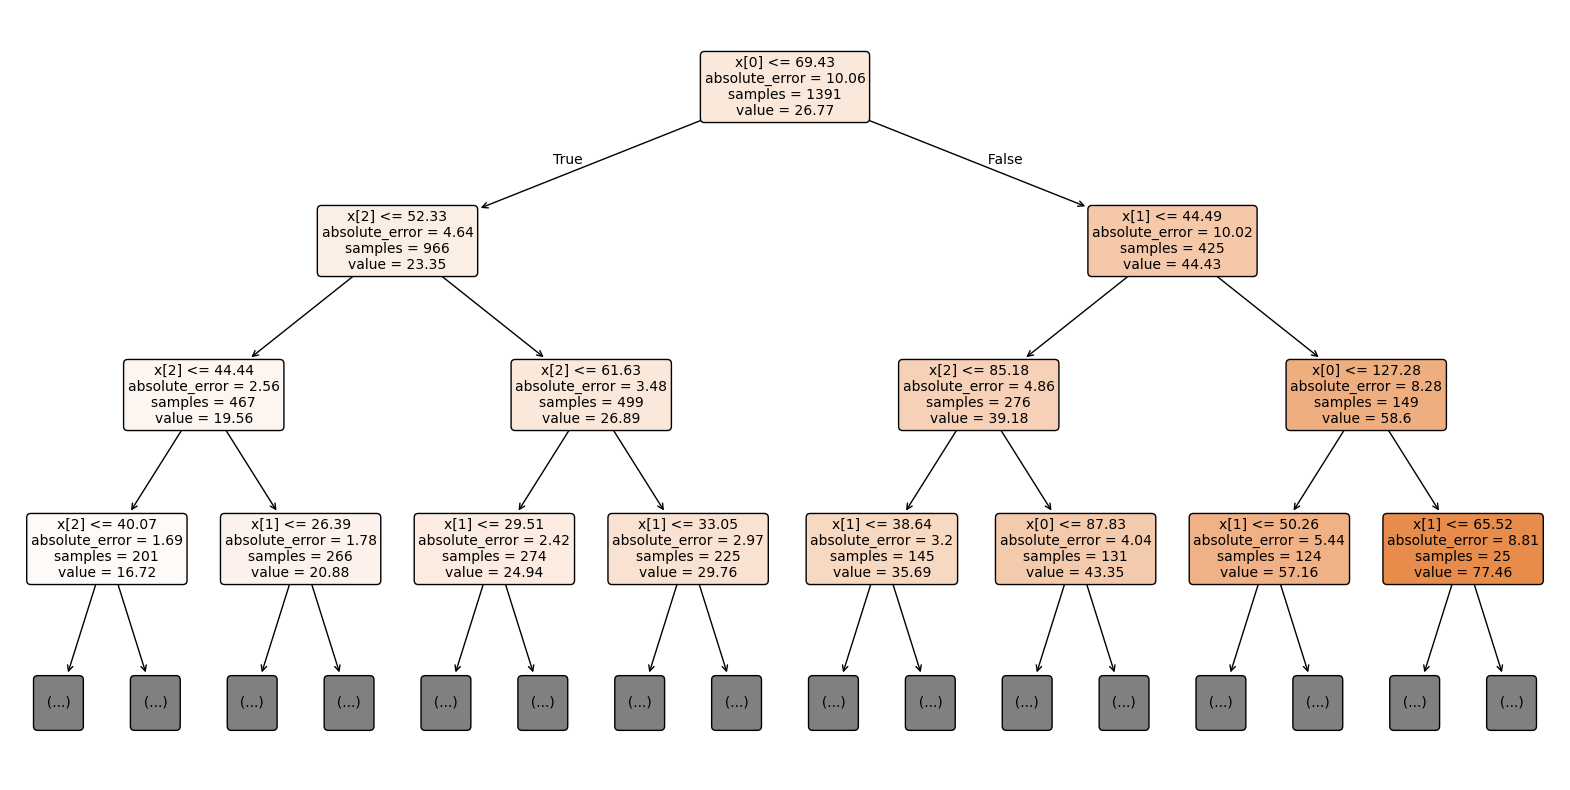

In [698]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_SMM,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 415 | 119.0850 |   83.8374 | 35.2476
 197 | 112.4690 |   83.8374 | 28.6316
 172 | 105.7740 |   83.8374 | 21.9366
 150 | 53.6596 |   36.5066 | 17.1530
 440 | 49.9916 |   34.1388 | 15.8528
 169 | 48.2171 |   34.1388 | 14.0783
   9 | 50.5667 |   36.5066 | 14.0601
  29 | 43.9279 |   29.9124 | 14.0155
  26 | 32.6623 |   18.6523 | 14.0100
  60 | 31.8455 |   18.6523 | 13.1932


C:\Users\paula\AppData\Local\Temp\ipykernel_26128\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


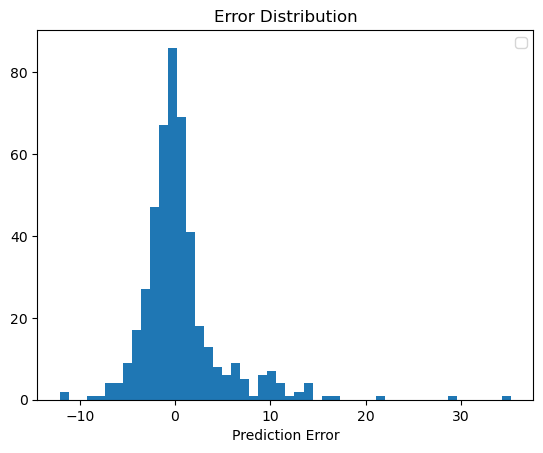

In [699]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [700]:
zipped = zip(attributes, dt_reg_SMM.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_LST 0.5343164176506863
BIA-BIA_FFM 0.256488339053753
BIA-BIA_ICW 0.2091952432955606


## TARGET VARIABLE BIA-BIA_Activity_Level_num

In [701]:
df_BIA_ACT_LEV= df[[
'BIA-BIA_DEE',
'BIA-BIA_FFM',
'BIA-BIA_LST',
'Physical-Weight',
'BIA-BIA_ICW',
'BIA-BIA_TBW',
'BIA-BIA_Activity_Level_num'
]]

In [702]:
df_BIA_ACT_LEV=df_BIA_ACT_LEV.dropna()

In [703]:
df_BIA_ACT_LEV.isnull().sum()

BIA-BIA_DEE                   0
BIA-BIA_FFM                   0
BIA-BIA_LST                   0
Physical-Weight               0
BIA-BIA_ICW                   0
BIA-BIA_TBW                   0
BIA-BIA_Activity_Level_num    0
dtype: int64

### Partitioning

In [704]:
attributes = [col for col in df_BIA_ACT_LEV.columns if col != 'BIA-BIA_Activity_Level_num']
X = df_BIA_ACT_LEV[attributes].values
y = np.array(df_BIA_ACT_LEV['BIA-BIA_Activity_Level_num'])

In [705]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0,stratify=y)


In [706]:
print(np.unique(y, return_counts=True)[1] / len(y))
print(np.unique(y_train, return_counts=True)[1] / len(y_train))
print(np.unique(y_test, return_counts=True)[1] / len(y_test))

[0.13469828 0.32165948 0.35344828 0.1487069  0.04148707]
[0.13433908 0.32183908 0.35344828 0.1487069  0.04166667]
[0.13577586 0.32112069 0.35344828 0.1487069  0.04094828]


In [707]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 6) (464, 6) (1392,) (464,)


In [708]:
df_BIA_ACT_LEV.shape

(1856, 7)

### Randomized Search

In [709]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 20)),
    'min_samples_split': [0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['gini', 'entropy']
}

dt_CL_ACT_LEV = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=0.002, min_samples_leaf=1)

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0),
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_CL_ACT_LEV = random_search.best_estimator_

In [710]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 19, 'criterion': 'entropy'} 0.8627781645651222


In [711]:
dt_CL_ACT_LEV = random_search.best_estimator_
dt_CL_ACT_LEV.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=19, min_samples_leaf=5,
                       min_samples_split=0.002)

In [712]:
y_pred = dt_CL_ACT_LEV.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.875
              precision    recall  f1-score   support

         1.0       0.95      0.92      0.94        63
         2.0       0.85      0.87      0.86       149
         3.0       0.86      0.88      0.87       164
         4.0       0.92      0.86      0.89        69
         5.0       0.79      0.79      0.79        19

    accuracy                           0.88       464
   macro avg       0.87      0.86      0.87       464
weighted avg       0.88      0.88      0.88       464



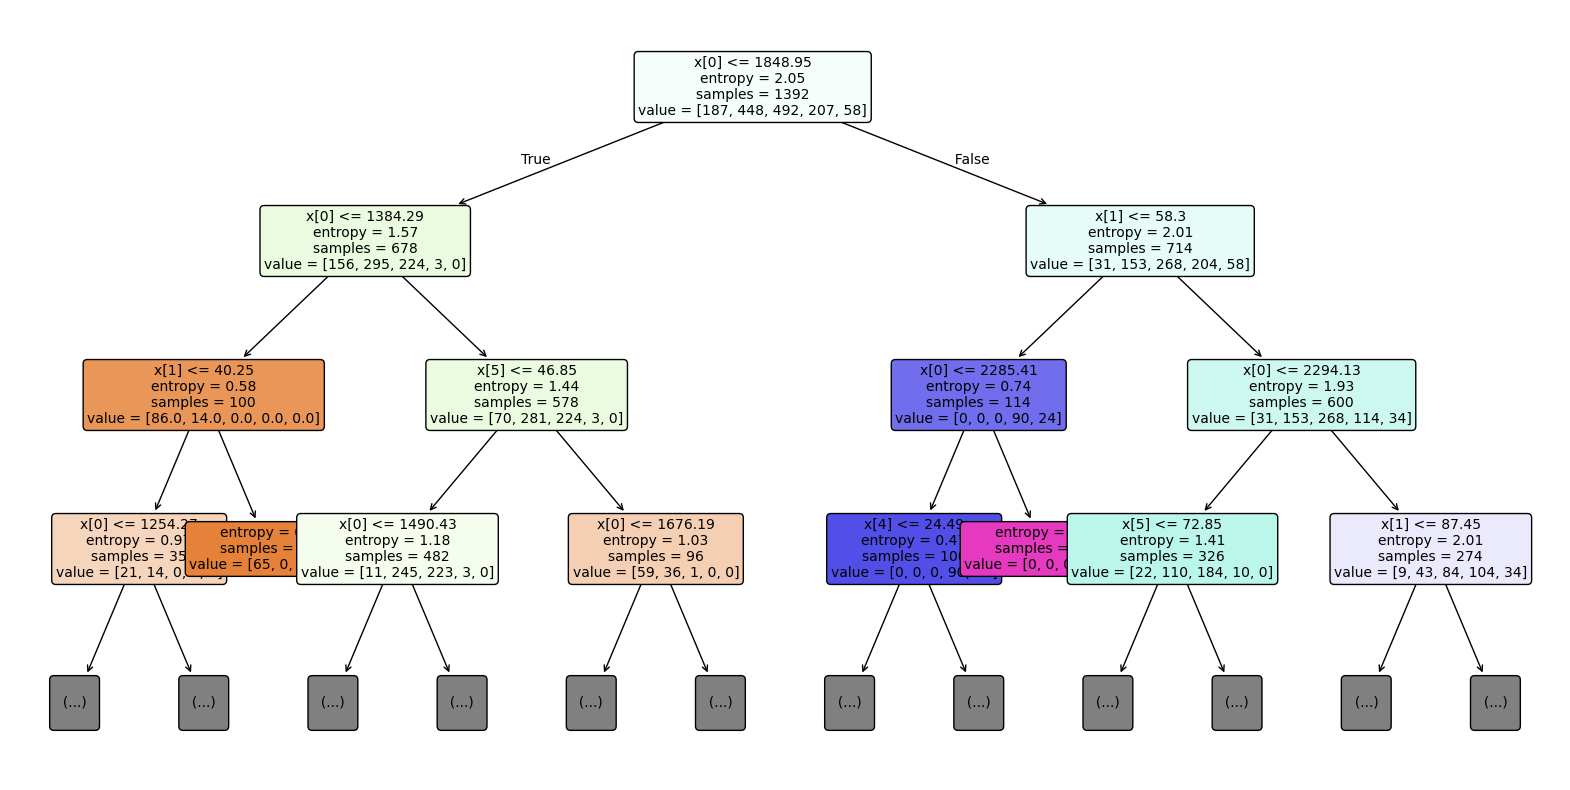

In [713]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_CL_ACT_LEV,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 439 |  5.0000 |    3.0000 | 2.0000
 463 |  3.0000 |    2.0000 | 1.0000
  91 |  5.0000 |    4.0000 | 1.0000
 136 |  2.0000 |    3.0000 | 1.0000
 137 |  4.0000 |    5.0000 | 1.0000
 420 |  5.0000 |    4.0000 | 1.0000
 160 |  4.0000 |    3.0000 | 1.0000
 191 |  2.0000 |    3.0000 | 1.0000
 140 |  4.0000 |    3.0000 | 1.0000
 414 |  1.0000 |    2.0000 | 1.0000


C:\Users\paula\AppData\Local\Temp\ipykernel_26128\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


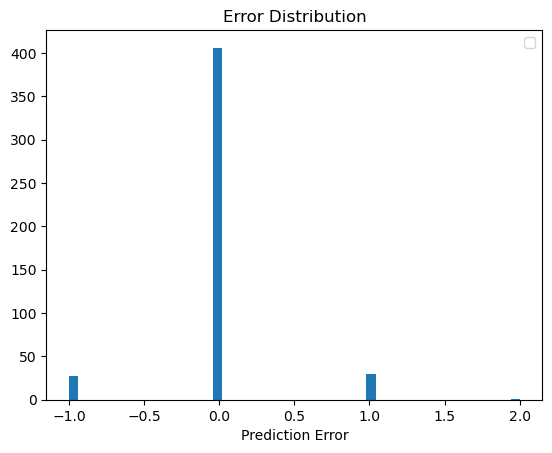

In [714]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [715]:
zipped = zip(attributes, dt_CL_ACT_LEV.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_DEE 0.49155404340585523
BIA-BIA_FFM 0.19100100437721326
BIA-BIA_TBW 0.12339892865327437
BIA-BIA_ICW 0.11433776704730769
BIA-BIA_LST 0.056982543852310226
Physical-Weight 0.02272571266403924


## TARGET VARIABLE BIA-BIA_Frame_num

In [716]:
df_BIA_Frame= df[[
       'Physical-Height', 
       'Physical-Weight',
       'BIA-BIA_Fat' ,
       'BIA-BIA_Frame_num'
]]

In [717]:
df_BIA_Frame=df_BIA_Frame.dropna()

In [718]:
df_BIA_Frame.isnull().sum()

Physical-Height      0
Physical-Weight      0
BIA-BIA_Fat          0
BIA-BIA_Frame_num    0
dtype: int64

### Partitioning

In [719]:
attributes = [col for col in df_BIA_Frame.columns if col != 'BIA-BIA_Frame_num']
X = df_BIA_Frame[attributes].values
y = np.array(df_BIA_Frame['BIA-BIA_Frame_num'])

In [720]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0,stratify=y)


In [721]:
print(np.unique(y, return_counts=True)[1] / len(y))
print(np.unique(y_train, return_counts=True)[1] / len(y_train))
print(np.unique(y_test, return_counts=True)[1] / len(y_test))

[0.39385776 0.47306034 0.1330819 ]
[0.39367816 0.47341954 0.1329023 ]
[0.39439655 0.47198276 0.13362069]


In [722]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 3) (464, 3) (1392,) (464,)


In [723]:
df_BIA_Frame.shape

(1856, 4)

### Randomized Search

In [724]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 40)),
    'min_samples_split': [0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['gini', 'entropy']
}

dt_reg_Frame = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=0.002, min_samples_leaf=1)

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0),
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_Frame = random_search.best_estimator_

In [725]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.05, 'min_samples_leaf': 5, 'max_depth': 3, 'criterion': 'entropy'} 0.6759805059178463


In [726]:
dt_reg_Frame = random_search.best_estimator_
dt_reg_Frame.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=5,
                       min_samples_split=0.05)

In [727]:
y_pred = dt_reg_Frame.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6530172413793104
              precision    recall  f1-score   support

         1.0       0.66      0.68      0.67       183
         2.0       0.63      0.72      0.67       219
         3.0       0.88      0.34      0.49        62

    accuracy                           0.65       464
   macro avg       0.72      0.58      0.61       464
weighted avg       0.67      0.65      0.65       464



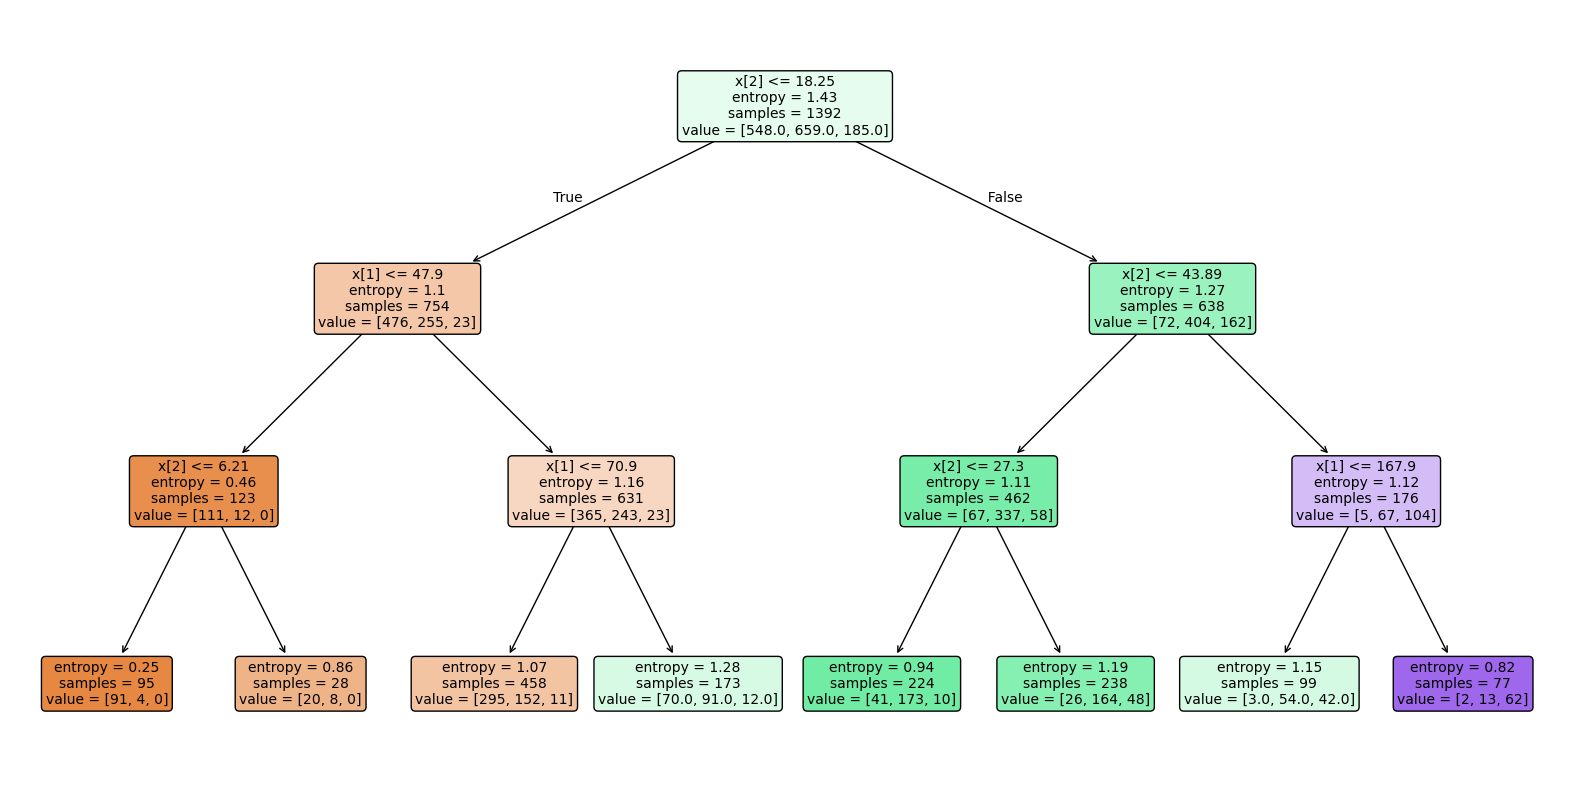

In [728]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_Frame,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 374 |  3.0000 |    1.0000 | 2.0000
 283 |  3.0000 |    1.0000 | 2.0000
 403 |  3.0000 |    1.0000 | 2.0000
 142 |  3.0000 |    1.0000 | 2.0000
  77 |  3.0000 |    1.0000 | 2.0000
   0 |  1.0000 |    2.0000 | 1.0000
  92 |  2.0000 |    1.0000 | 1.0000
 321 |  1.0000 |    2.0000 | 1.0000
 319 |  1.0000 |    2.0000 | 1.0000
 317 |  1.0000 |    2.0000 | 1.0000


C:\Users\paula\AppData\Local\Temp\ipykernel_26128\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


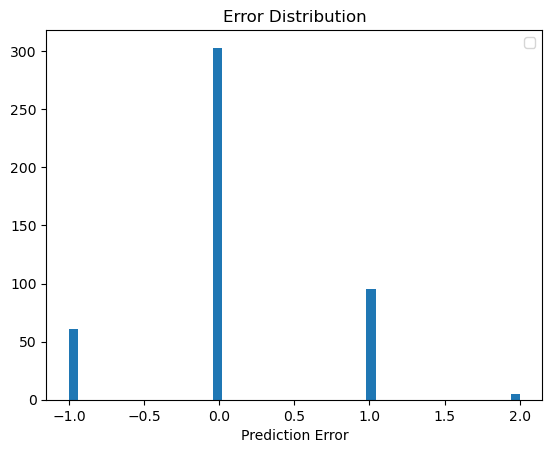

In [729]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [730]:
zipped = zip(attributes, dt_reg_Frame.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_Fat 0.8497176180587473
Physical-Weight 0.1502823819412526
Physical-Height 0.0


## ** TARGET VARIABLE Physical-HeartRate

In [731]:
df_HeartRate = df[[
       'Physical-HeartRate', 
       'Physical-Height',
       'Physical-Weight',
       'Physical-MAP_CAL'
       ]].copy()


In [732]:
df_HeartRate=df_HeartRate.dropna()

In [733]:
df_HeartRate.isnull().sum()

Physical-HeartRate    0
Physical-Height       0
Physical-Weight       0
Physical-MAP_CAL      0
dtype: int64

### Partitioning

In [734]:
attributes = [col for col in df_HeartRate.columns if col != 'Physical-HeartRate']
X = df_HeartRate[attributes].values
y = np.array(df_HeartRate['Physical-HeartRate'])

In [735]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [736]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1389, 3) (464, 3) (1389,) (464,)


In [737]:
df_HeartRate.shape

(1853, 4)

### Randomized Search

In [738]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [739]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_HeartRate = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_HeartRate = random_search.best_estimator_

In [740]:
# param_list = {
#     'n_estimators': [50, 100, 200, 300, 500],
#     'max_depth': [None] + list(np.arange(2, 50)),
#     'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
#     'max_features': ['sqrt', 'log2', None] # Optional: highly recommended to tune for RFs
# }

# rf_reg_HeartRate = RandomForestRegressor(random_state=0)


# random_search = RandomizedSearchCV(
#     estimator=RandomForestRegressor(random_state=0),    
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0), 
#     scoring='neg_mean_squared_error',   
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
#     random_state=0 # Ensures the random search picks the same combinations on reruns
# )

# random_search.fit(X_train, y_train)
# dt_reg_HeartRate = random_search.best_estimator_

In [741]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.2, 'min_samples_leaf': 50, 'max_depth': 29, 'criterion': 'absolute_error'} -159.28568228449734


In [742]:
dt_reg_HeartRate = random_search.best_estimator_
dt_reg_HeartRate.fit(X_train, y_train)

DecisionTreeRegressor(criterion='absolute_error', max_depth=29,
                      min_samples_leaf=50, min_samples_split=0.2)

In [743]:
y_pred = dt_reg_HeartRate.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 12.9506
MAE  : 10.6519
MSE  : 167.7193
R²   : -0.0140


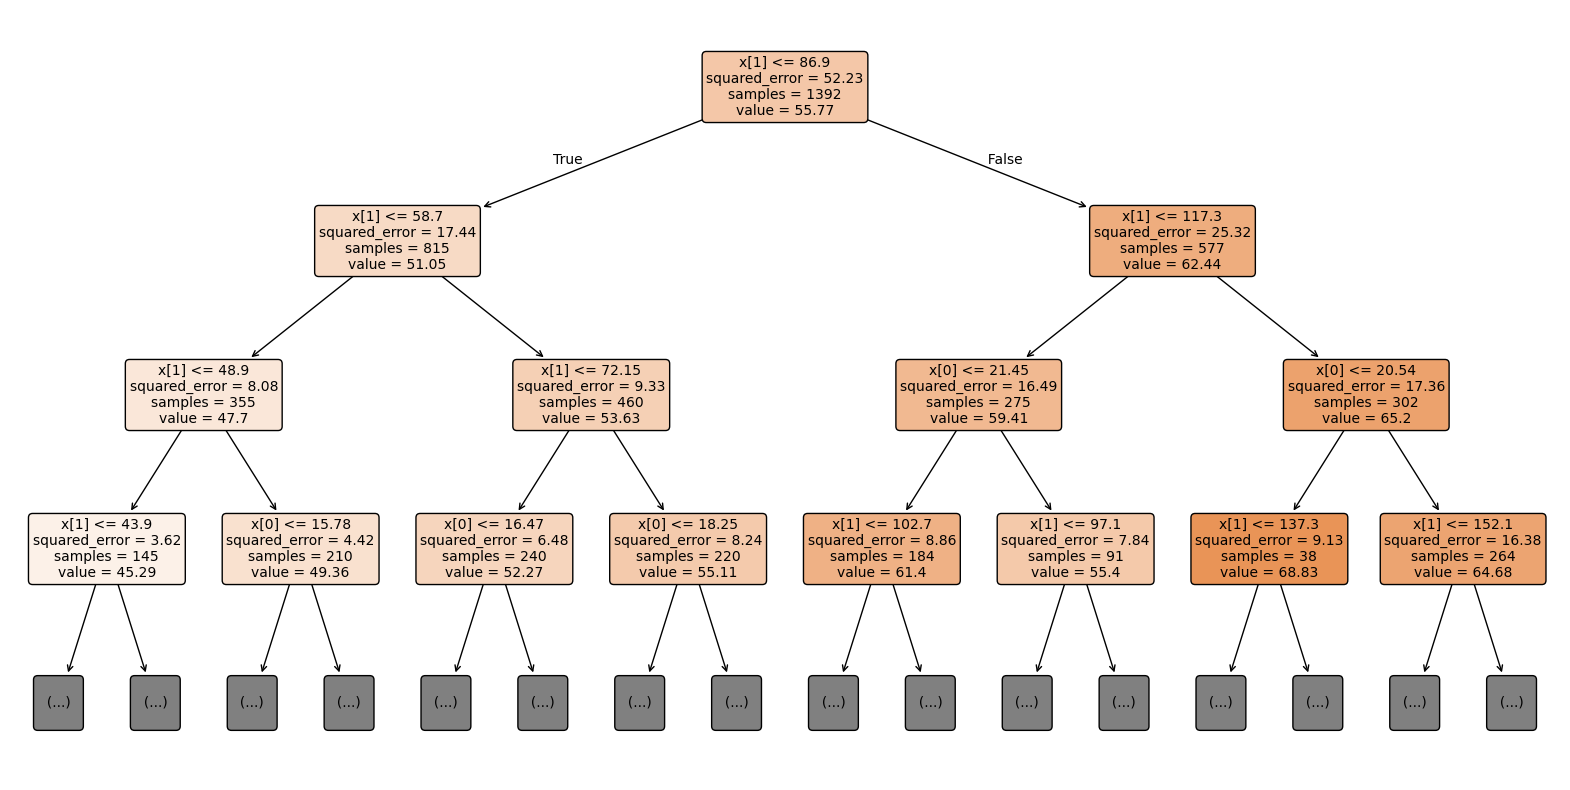

In [744]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_height,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 358 | 46.0000 |   91.0000 | 45.0000
 443 | 118.0000 |   78.0000 | 40.0000
 296 | 113.0000 |   78.0000 | 35.0000
  72 | 107.0000 |   73.0000 | 34.0000
 109 | 112.0000 |   78.0000 | 34.0000
 151 | 120.0000 |   87.5000 | 32.5000
 424 | 111.0000 |   82.0000 | 29.0000
 240 | 62.0000 |   91.0000 | 29.0000
 219 | 116.0000 |   87.5000 | 28.5000
 348 | 63.0000 |   91.0000 | 28.0000


C:\Users\paula\AppData\Local\Temp\ipykernel_26128\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


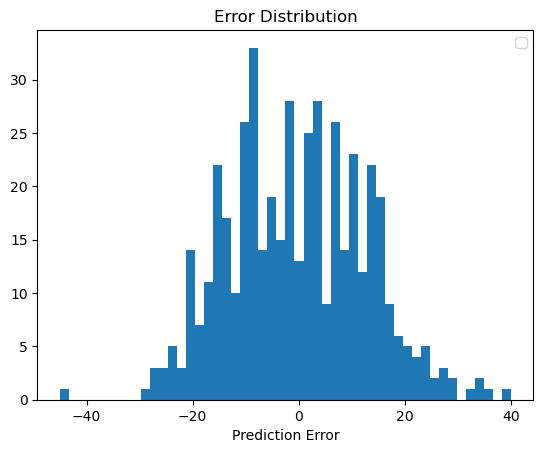

In [745]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [746]:
zipped = zip(attributes, dt_reg_HeartRate.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Physical-Height 0.5092667203867849
Physical-MAP_CAL 0.4907332796132152
Physical-Weight 0.0


## ** TARGET VARIABLE CGAS-CGAS_Score'

In [747]:
df_CGAS_Score = df[[
'CGAS-CGAS_Score', 
'SDS-SDS_Total_T',
'Physical-BMI',
'FGC-FGC_CORE_CAL',
'Physical-Weight',
"BIA-BIA_Activity_Level_num",
#"FGC-FGC_CORE_CAL",
"Basic_Demos-Sex",
"BIA-BIA_Frame_num",      
       ]].copy()



In [748]:
df_CGAS_Score=df_CGAS_Score.dropna()

In [749]:
df_CGAS_Score.isnull().sum()

CGAS-CGAS_Score               0
Physical-BMI                  0
FGC-FGC_CORE_CAL              0
Physical-Weight               0
BIA-BIA_Activity_Level_num    0
FGC-FGC_CORE_CAL              0
Basic_Demos-Sex               0
Physical-BMI                  0
BIA-BIA_Frame_num             0
dtype: int64

### Partitioning

In [750]:
attributes = [col for col in df_CGAS_Score.columns if col != 'CGAS-CGAS_Score']
X = df_CGAS_Score[attributes].values
y = np.array(df_CGAS_Score['CGAS-CGAS_Score'])

In [751]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [752]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1038, 12) (346, 12) (1038,) (346,)


In [753]:
df_CGAS_Score.shape

(1384, 9)

### Randomized Search

In [754]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [755]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_CGAS_Score = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_CGAS_Score = random_search.best_estimator_

In [756]:
# param_list = {
#     'n_estimators': [50, 100, 200, 300, 500],
#     'max_depth': [None] + list(np.arange(2, 50)),
#     'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
#     'max_features': ['sqrt', 'log2', None] # Optional: highly recommended to tune for RFs
# }

# dt_reg_CGAS_Score = RandomForestRegressor(random_state=0)


# random_search = RandomizedSearchCV(
#     estimator=RandomForestRegressor(random_state=0),    
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0), 
#     scoring='neg_mean_squared_error',   
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
#     random_state=0 # Ensures the random search picks the same combinations on reruns
# )

# random_search.fit(X_train, y_train)
# dt_reg_CGAS_Score = random_search.best_estimator_

In [757]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.002, 'min_samples_leaf': 100, 'max_depth': 3, 'criterion': 'squared_error'} -122.63788619260727


In [758]:
dt_reg_CGAS_Score = random_search.best_estimator_
dt_reg_CGAS_Score.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3, min_samples_leaf=100,
                      min_samples_split=0.002)

In [759]:
y_pred = dt_reg_CGAS_Score.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 11.1533
MAE  : 9.0567
MSE  : 124.3963
R²   : 0.0038


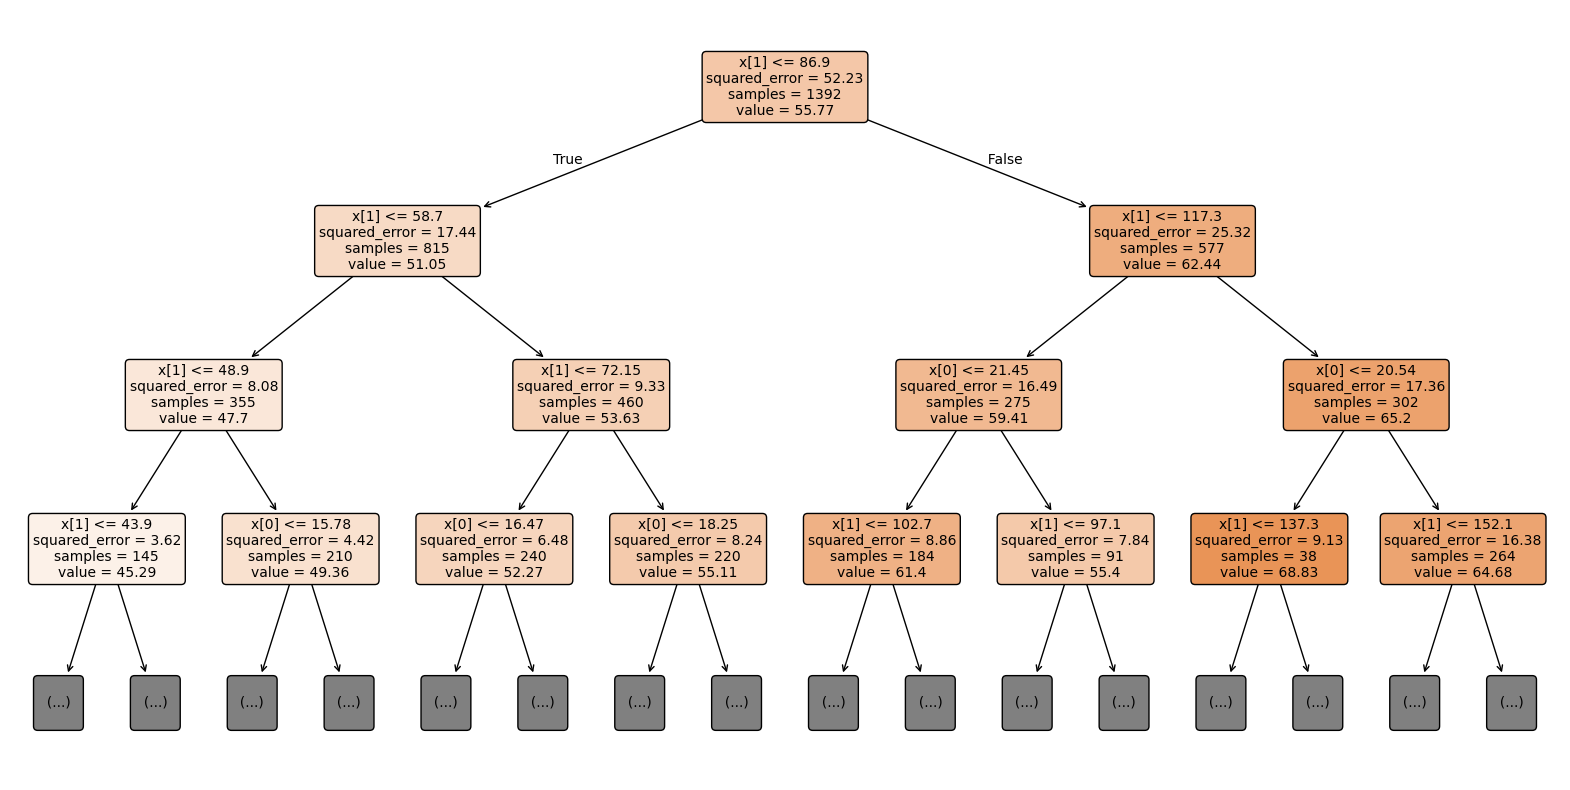

In [760]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_height,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
  98 | 39.0000 |   69.9022 | 30.9022
 345 | 40.0000 |   67.8304 | 27.8304
 162 | 41.0000 |   67.2373 | 26.2373
 117 | 41.0000 |   67.2373 | 26.2373
 301 | 90.0000 |   64.0580 | 25.9420
 125 | 45.0000 |   69.9022 | 24.9022
 250 | 92.0000 |   67.8304 | 24.1696
 220 | 91.0000 |   67.8304 | 23.1696
 160 | 45.0000 |   67.8304 | 22.8304
 154 | 45.0000 |   67.8304 | 22.8304


C:\Users\paula\AppData\Local\Temp\ipykernel_26128\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


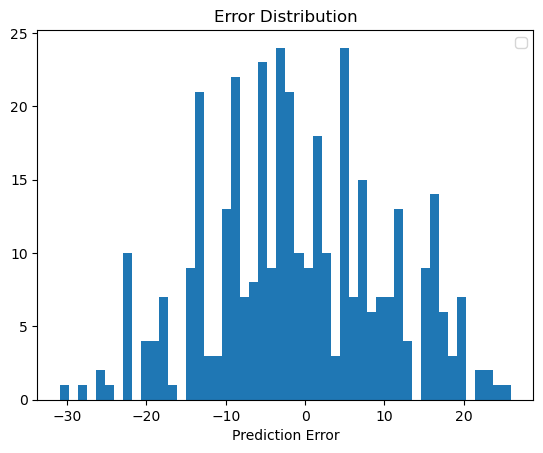

In [761]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [762]:
zipped = zip(attributes, dt_reg_CGAS_Score.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

SDS-SDS_Total_T 0.390062618848251
FGC-FGC_CORE_CAL 0.37908151418651403
Physical-Weight 0.16720230421270094
Physical-BMI 0.06365356275253412


## ** TARGET VARIABLE Fitness_Endurance-Max_Stage

In [763]:
df_Fitness_Endurance= df[[
'Physical-Weight',
'FGC-FGC_CORE_CAL',
'Basic_Demos-Age',
'Basic_Demos-Sex', 
'Physical-Height',
'BIA-BIA_FMI',
'Physical-MAP_CAL',
'BIA-BIA_TBW',
'Fitness_Endurance-Max_Stage'
]]



In [764]:
df_Fitness_Endurance=df_Fitness_Endurance.dropna()

In [765]:
df_Fitness_Endurance.isnull().sum()

Physical-Weight                0
FGC-FGC_CORE_CAL               0
Basic_Demos-Age                0
Basic_Demos-Sex                0
Physical-Height                0
BIA-BIA_FMI                    0
Physical-MAP_CAL               0
BIA-BIA_TBW                    0
Fitness_Endurance-Max_Stage    0
dtype: int64

### Partitioning

In [766]:
attributes = [col for col in df_Fitness_Endurance.columns if col != 'Fitness_Endurance-Max_Stage']
X = df_Fitness_Endurance[attributes].values
y = np.array(df_Fitness_Endurance['Fitness_Endurance-Max_Stage'])

In [767]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0, stratify = y)


In [768]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(861, 8) (288, 8) (861,) (288,)


In [769]:
df_Fitness_Endurance.shape

(1149, 9)

### Randomized Search

In [770]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 20)),
    'min_samples_split': [0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['gini', 'entropy']
}

dt_reg_Fitness_Endurance = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=0.002, min_samples_leaf=1)

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0),
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_Fitness_Endurance = random_search.best_estimator_

In [771]:
# param_list = {
#     'n_estimators': [50, 100, 200, 300, 500],
#     'max_depth': [None] + list(np.arange(2, 50)),
#     'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
#     'max_features': ['sqrt', 'log2', None] # Optional: highly recommended to tune for RFs
# }

# dt_reg_Fitness_Endurance = RandomForestRegressor(random_state=0)


# random_search = RandomizedSearchCV(
#     estimator=RandomForestRegressor(random_state=0),    
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0), 
#     scoring='neg_mean_squared_error',   
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
#     random_state=0 # Ensures the random search picks the same combinations on reruns
# )

# random_search.fit(X_train, y_train)
# dt_reg_Fitness_Endurance = random_search.best_estimator_

In [772]:
# param_list = {
#     'n_estimators': [50, 100, 200, 300, 500],
#     'max_depth': [None] + list(np.arange(2, 20)),
#     'min_samples_split': [0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['gini', 'entropy']
# }

# dt_reg_Fitness_Endurance = RandomForestClassifier(random_state=0)

# random_search = RandomizedSearchCV(
#     estimator=RandomForestClassifier(random_state=0), # Added random_state for reproducibility
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0),
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
#     random_state=0 # Good practice for RandomizedSearchCV
# )

# random_search.fit(X_train, y_train)
# dt_reg_Fitness_Endurance = random_search.best_estimator_

In [773]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.05, 'min_samples_leaf': 10, 'max_depth': 3, 'criterion': 'gini'} 0.6814487415592388


In [774]:
dt_reg_Fitness_Endurance = random_search.best_estimator_
dt_reg_Fitness_Endurance.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, min_samples_split=0.05)

In [775]:
y_pred = dt_reg_Fitness_Endurance.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7118055555555556
              precision    recall  f1-score   support

         3.0       0.00      0.00      0.00        11
         4.0       0.00      0.00      0.00        25
         5.0       0.72      1.00      0.83       203
         6.0       0.50      0.09      0.15        34
         7.0       0.00      0.00      0.00        13
         8.0       0.00      0.00      0.00         2

    accuracy                           0.71       288
   macro avg       0.20      0.18      0.16       288
weighted avg       0.56      0.71      0.60       288



/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

In [776]:
y_pred = dt_reg_Fitness_Endurance.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 0.7523
MAE  : 0.3785
MSE  : 0.5660
R²   : 0.0509


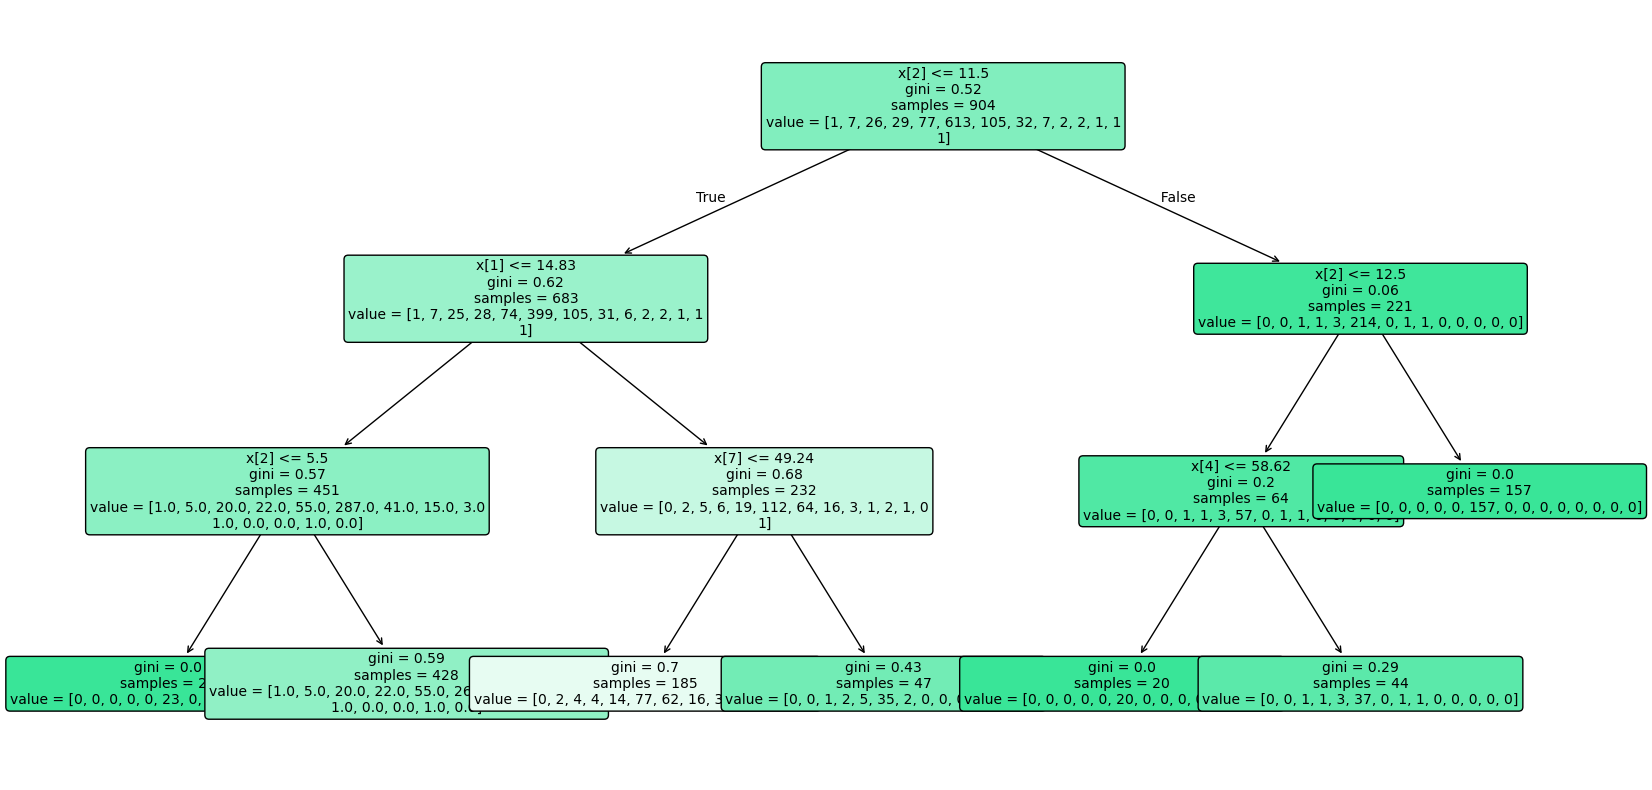

In [777]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_Fitness_Endurance,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
   5 |  8.0000 |    5.0000 | 3.0000
 138 |  3.0000 |    5.0000 | 2.0000
  96 |  3.0000 |    5.0000 | 2.0000
 259 |  7.0000 |    5.0000 | 2.0000
 156 |  3.0000 |    5.0000 | 2.0000
  95 |  7.0000 |    5.0000 | 2.0000
 254 |  3.0000 |    5.0000 | 2.0000
 264 |  7.0000 |    5.0000 | 2.0000
 161 |  3.0000 |    5.0000 | 2.0000
 135 |  7.0000 |    5.0000 | 2.0000


C:\Users\paula\AppData\Local\Temp\ipykernel_26128\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


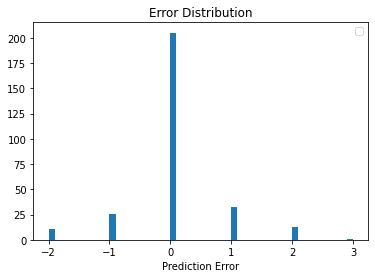

In [778]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [779]:
zipped = zip(attributes, dt_reg_Fitness_Endurance.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Basic_Demos-Age 0.668390139758793
FGC-FGC_CORE_CAL 0.17917612435459346
BIA-BIA_TBW 0.1441131726038016
Physical-Height 0.00832056328281192
Physical-Weight 0.0
Basic_Demos-Sex 0.0
BIA-BIA_FMI 0.0
Physical-MAP_CAL 0.0


## ** TARGET VARIABLE FGC-FGC_TL

In [780]:
df_FGC_TL= df[[
'FGC-FGC_TL',
'FGC-FGC_CORE_CAL',
'FGC-FGC_SR_CAL',
'BIA-BIA_ECW',
'Basic_Demos-Age',
'Basic_Demos-Sex',
'Physical-Weight',
'Physical-Height',
'BIA-BIA_TBW'
]]





In [781]:
df_FGC_TL=df_FGC_TL.dropna()

In [782]:
df_FGC_TL.isnull().sum()

FGC-FGC_TL          0
FGC-FGC_CORE_CAL    0
FGC-FGC_SR_CAL      0
BIA-BIA_ECW         0
Basic_Demos-Age     0
Basic_Demos-Sex     0
Physical-Weight     0
Physical-Height     0
BIA-BIA_TBW         0
dtype: int64

### Partitioning

In [783]:
attributes = [col for col in df_FGC_TL.columns if col != 'FGC-FGC_TL']
X = df_FGC_TL[attributes].values
y = np.array(df_FGC_TL['FGC-FGC_TL'])

In [784]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [785]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1281, 8) (427, 8) (1281,) (427,)


In [786]:
df_FGC_TL.shape

(1708, 9)

### Randomized Search

In [787]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [788]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_FGC_TL = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=10, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_FGC_TL = random_search.best_estimator_

In [789]:
# param_list = {
#     'n_estimators': [50, 100, 200, 300, 500],
#     'max_depth': [None] + list(np.arange(2, 50)),
#     'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
#     'max_features': ['sqrt', 'log2', None] # Optional: highly recommended to tune for RFs
# }

# dt_reg_FGC_TL = RandomForestRegressor(random_state=0)


# random_search = RandomizedSearchCV(
#     estimator=RandomForestRegressor(random_state=0),    
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0), 
#     scoring='neg_mean_squared_error',   
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
#     random_state=0 # Ensures the random search picks the same combinations on reruns
# )

# random_search.fit(X_train, y_train)
# dt_reg_FGC_TL = random_search.best_estimator_

In [790]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.1, 'min_samples_leaf': 100, 'max_depth': 3, 'criterion': 'friedman_mse'} -6.668359302191194


In [791]:
dt_reg_FGC_TL = random_search.best_estimator_
dt_reg_FGC_TL.fit(X_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                      min_samples_leaf=100, min_samples_split=0.1)

In [792]:
y_pred = dt_reg_FGC_TL.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 2.6475
MAE  : 2.1156
MSE  : 7.0090
R²   : 0.1387


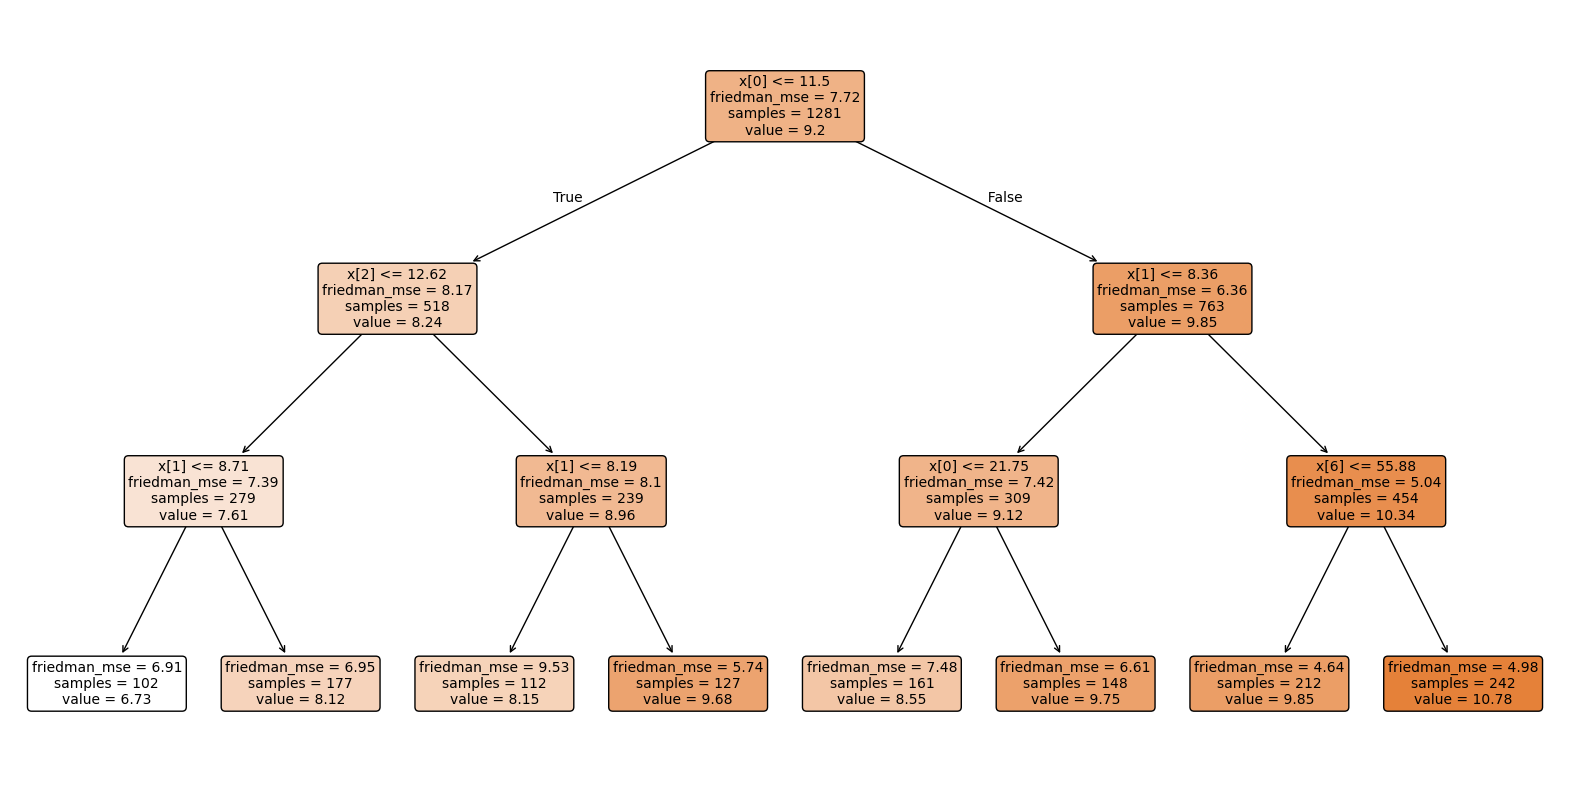

In [793]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_FGC_TL,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
  43 |  0.0000 |    9.7466 | 9.7466
  38 | 19.0000 |    9.7466 | 9.2534
 296 |  0.0000 |    8.1243 | 8.1243
 242 |  3.0000 |    9.8495 | 6.8495
 384 |  0.0000 |    6.7255 | 6.7255
   4 | 17.0000 |   10.7764 | 6.2236
 115 |  2.0000 |    8.1518 | 6.1518
 143 |  5.0000 |   10.7764 | 5.7764
  11 |  5.0000 |   10.7764 | 5.7764
  47 |  4.0000 |    9.7466 | 5.7466


C:\Users\paula\AppData\Local\Temp\ipykernel_26128\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


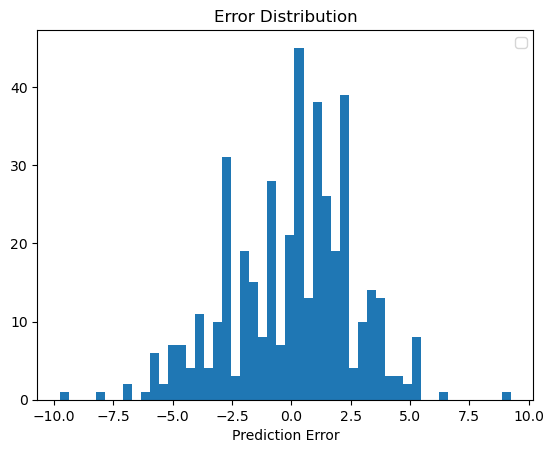

In [794]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [795]:
zipped = zip(attributes, dt_reg_FGC_TL.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

FGC-FGC_CORE_CAL 0.5122608494404893
FGC-FGC_SR_CAL 0.3019452098307756
BIA-BIA_ECW 0.13137843669247226
Physical-Height 0.05441550403626281
Basic_Demos-Age 0.0
Basic_Demos-Sex 0.0
Physical-Weight 0.0
BIA-BIA_TBW 0.0


## ** TARGET VARIABLE SDS-SDS_Total_T

In [796]:
df_SDS_Total= df[[
'SDS-SDS_Total_T',
'Basic_Demos-Age','Basic_Demos-Sex', 'Physical-Weight',
'Physical-Height','BIA-BIA_FFMI',
        'BIA-BIA_Fat'
]]




In [797]:
df_SDS_Total=df_SDS_Total.dropna()

In [798]:
df_SDS_Total.isnull().sum()

SDS-SDS_Total_T    0
Basic_Demos-Age    0
Basic_Demos-Sex    0
Physical-Weight    0
Physical-Height    0
BIA-BIA_FFMI       0
BIA-BIA_Fat        0
dtype: int64

### Partitioning

In [799]:
attributes = [col for col in df_SDS_Total.columns if col != 'SDS-SDS_Total_T']
X = df_SDS_Total[attributes].values
y = np.array(df_SDS_Total['SDS-SDS_Total_T'])

In [800]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [801]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1194, 6) (399, 6) (1194,) (399,)


In [802]:
df_SDS_Total.shape

(1593, 7)

### Randomized Search

In [803]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [804]:
param_list = {
    'max_depth': [None] + list(np.arange(10, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_SDS_Total = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_SDS_Total = random_search.best_estimator_

In [805]:
# param_list = {
#     'n_estimators': [50, 100, 200, 300, 500],
#     'max_depth': [None] + list(np.arange(2, 50)),
#     'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
#     'max_features': ['sqrt', 'log2', None] # Optional: highly recommended to tune for RFs
# }

# dt_reg_SDS_Total = RandomForestRegressor(random_state=0)


# random_search = RandomizedSearchCV(
#     estimator=RandomForestRegressor(random_state=0),    
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0), 
#     scoring='neg_mean_squared_error',   
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
#     random_state=0 # Ensures the random search picks the same combinations on reruns
# )

# random_search.fit(X_train, y_train)
# dt_reg_SDS_Total = random_search.best_estimator_

In [806]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.1, 'min_samples_leaf': 150, 'max_depth': 11, 'criterion': 'squared_error'} -178.70670499660747


In [807]:
dt_reg_SDS_Total = random_search.best_estimator_
dt_reg_SDS_Total.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=11, min_samples_leaf=150, min_samples_split=0.1)

In [808]:
y_pred = dt_reg_SDS_Total.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 13.0788
MAE  : 10.1485
MSE  : 171.0545
R²   : -0.0229


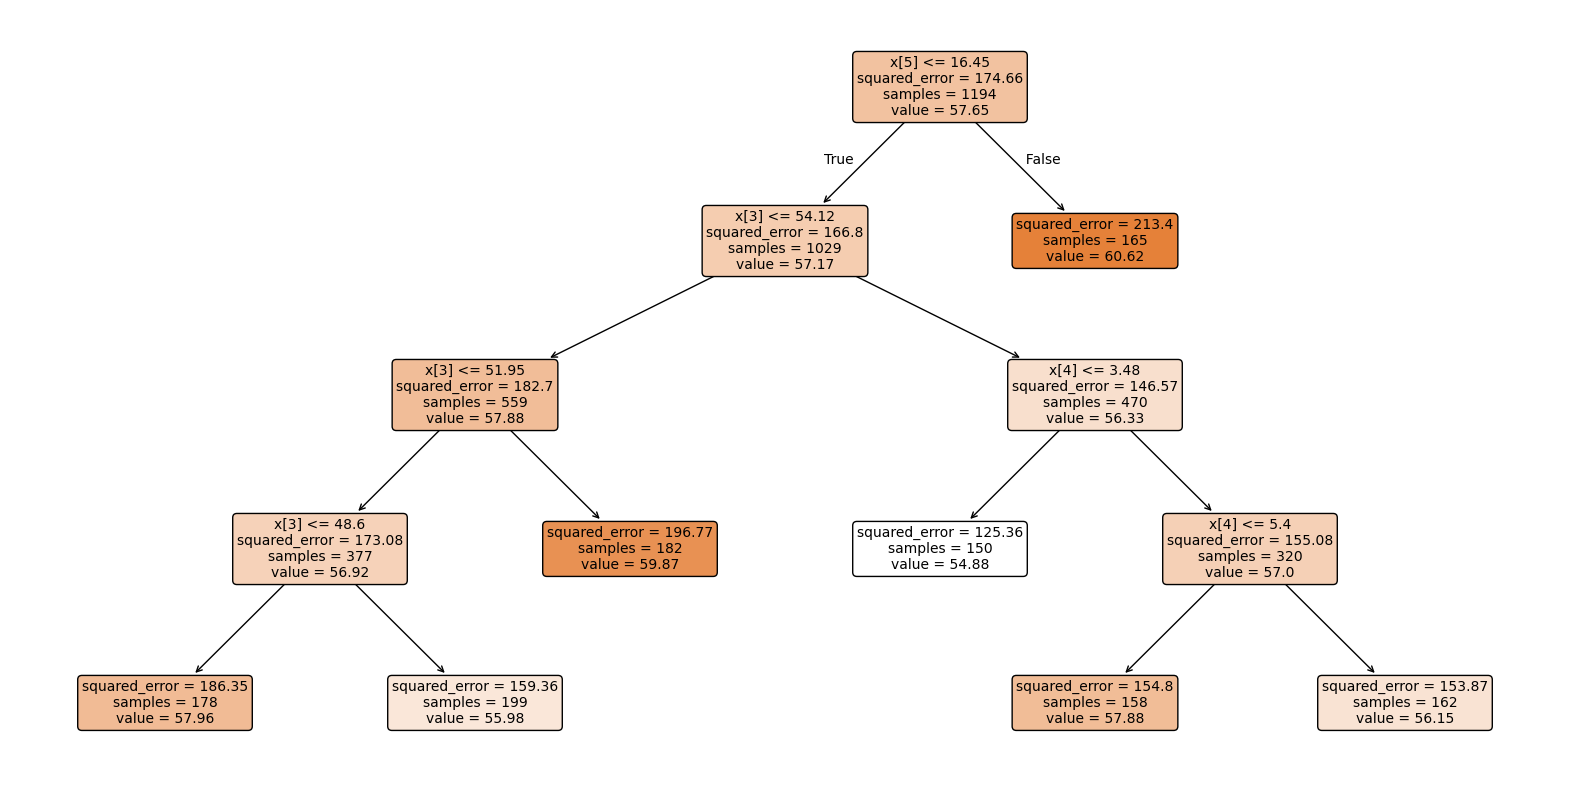

In [809]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_SDS_Total,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 4
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 204 | 100.0000 |   54.9333 | 45.0667
  40 | 100.0000 |   55.9849 | 44.0151
 306 | 100.0000 |   55.9849 | 44.0151
 245 | 100.0000 |   57.9607 | 42.0393
 357 | 100.0000 |   58.1562 | 41.8438
 340 | 99.0000 |   59.8681 | 39.1319
 127 | 94.0000 |   54.9333 | 39.0667
 339 | 95.0000 |   59.8681 | 35.1319
 101 | 91.0000 |   55.9849 | 35.0151
  46 | 90.0000 |   55.9849 | 34.0151


C:\Users\paula\AppData\Local\Temp\ipykernel_26128\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


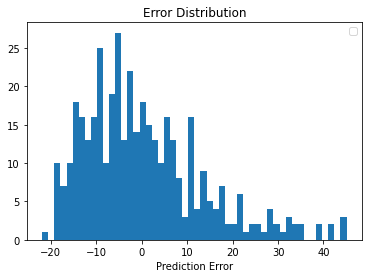

In [810]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [811]:
zipped = zip(attributes, dt_reg_SDS_Total.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Physical-Height 0.44452143280328443
BIA-BIA_FFMI 0.36665509838226706
BIA-BIA_Fat 0.18882346881444853
Basic_Demos-Age 0.0
Basic_Demos-Sex 0.0
Physical-Weight 0.0


## ** TARGET VARIABLE PreInt_EduHx-computerinternet_hoursday'

In [812]:
df_computerinternet= df[[
'Basic_Demos-Age',# 'CGAS-CGAS_Score', 
       #'Physical-Height',
         'Physical-Weight', #'BIA-BIA_BMR',
       #'Physical-HeartRate', 'FGC-FGC_TL',
       #'BIA-BIA_Frame_num', 'BIA-BIA_SMM', 'BIA-BIA_TBW',
       'PreInt_EduHx-computerinternet_hoursday', "BIA-BIA_Fat"
]]



In [813]:
df_computerinternet=df_computerinternet.dropna()

In [814]:
df_computerinternet.isnull().sum()

Basic_Demos-Age                           0
Physical-Weight                           0
PreInt_EduHx-computerinternet_hoursday    0
BIA-BIA_Fat                               0
dtype: int64

### Partitioning

In [815]:
attributes = [col for col in df_computerinternet.columns if col != 'PreInt_EduHx-computerinternet_hoursday']
X = df_computerinternet[attributes].values
y = np.array(df_computerinternet['PreInt_EduHx-computerinternet_hoursday'])

In [816]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0, stratify = y)


In [817]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1279, 3) (549, 3) (1279,) (549,)


In [818]:
df_computerinternet.shape

(1828, 4)

### Randomized Search

In [819]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [820]:
# param_list = {
#     'max_depth': [None] + list(np.arange(10, 50)),
#     'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
# }

# dt_reg_computerinternet = DecisionTreeRegressor()  

# random_search = RandomizedSearchCV(
#     DecisionTreeRegressor(),    
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0), 
#     scoring='neg_mean_squared_error' ,   
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
# )

# random_search.fit(X_train, y_train)
# dt_reg_computerinternet = random_search.best_estimator_

In [821]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.1, 'min_samples_leaf': 150, 'max_depth': 11, 'criterion': 'squared_error'} -178.70670499660747


In [822]:
dt_reg_computerinternet = random_search.best_estimator_
dt_reg_computerinternet.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=11, min_samples_leaf=150, min_samples_split=0.1)

In [823]:
"""y_pred = dt_reg_computerinternet.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable"""

y_pred = dt_reg_computerinternet.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5409836065573771
              precision    recall  f1-score   support

         0.0       0.61      0.75      0.67       249
         1.0       0.00      0.00      0.00        79
         2.0       0.44      0.55      0.49       169
         3.0       0.50      0.35      0.41        52

    accuracy                           0.54       549
   macro avg       0.39      0.41      0.39       549
weighted avg       0.46      0.54      0.50       549



/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

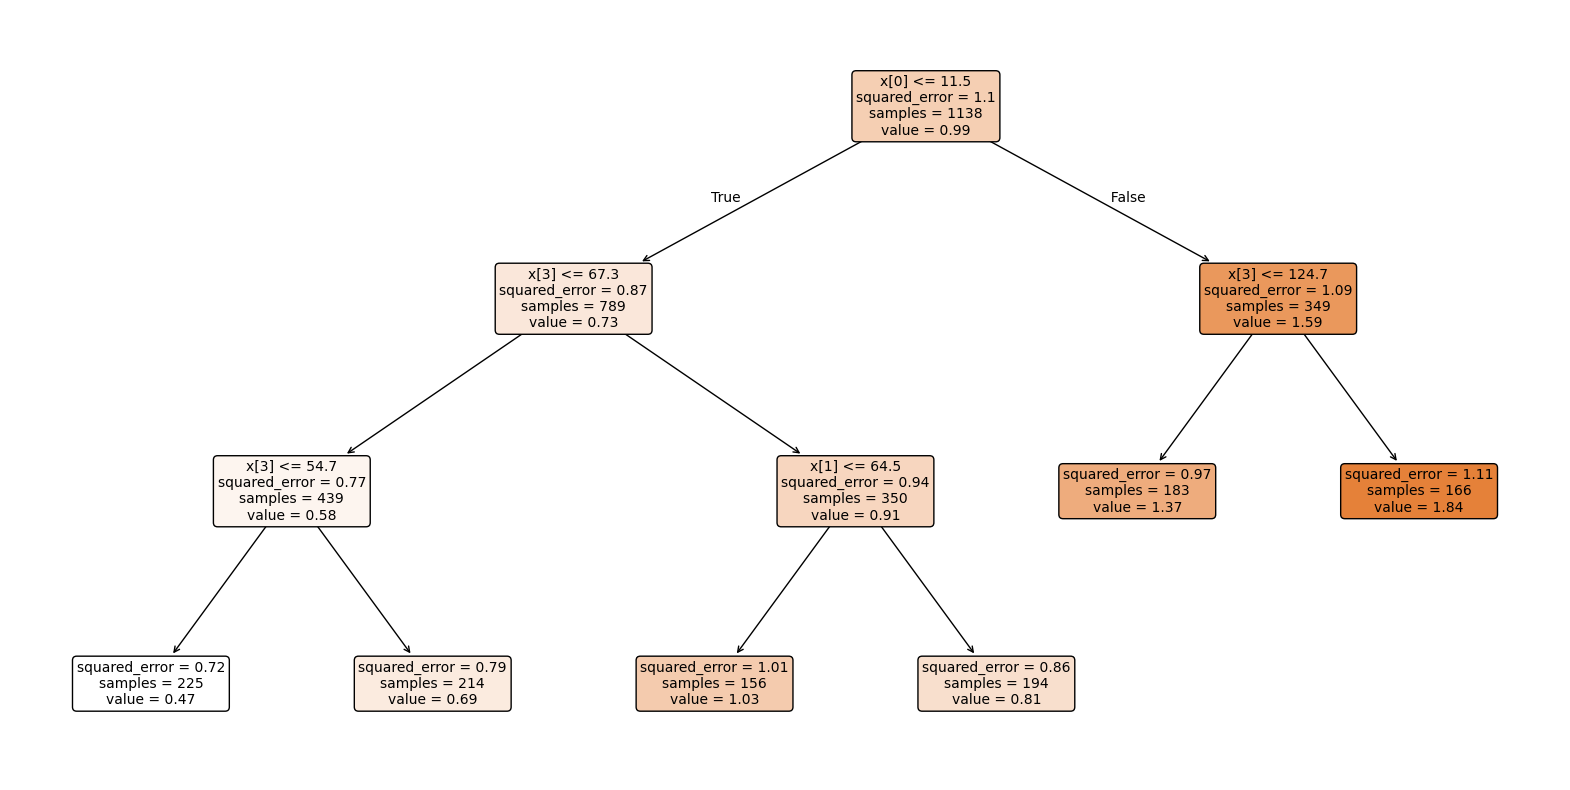

In [824]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_computerinternet,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 4
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 203 |  0.0000 |    3.0000 | 3.0000
  26 |  3.0000 |    0.0000 | 3.0000
 144 |  3.0000 |    0.0000 | 3.0000
 109 |  3.0000 |    0.0000 | 3.0000
   9 |  0.0000 |    3.0000 | 3.0000
 525 |  3.0000 |    0.0000 | 3.0000
 260 |  3.0000 |    0.0000 | 3.0000
  21 |  3.0000 |    0.0000 | 3.0000
 267 |  0.0000 |    3.0000 | 3.0000
  53 |  3.0000 |    0.0000 | 3.0000


C:\Users\paula\AppData\Local\Temp\ipykernel_26128\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


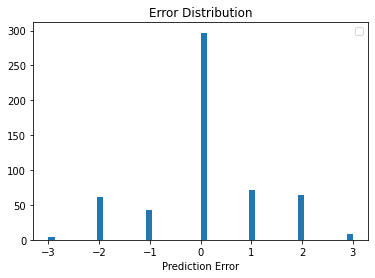

In [825]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [826]:
zipped = zip(attributes, dt_reg_computerinternet.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Physical-Weight 0.5880320537930868
Basic_Demos-Age 0.2515187868909588
BIA-BIA_Fat 0.16044915931595433


# IMPORT TOTAL DATASET

In [827]:
file_path = "../1.DATASET/CMI_V2.csv"
df_notna=pd.read_csv(file_path)
df_notna

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,0,5,0,51.0,16.877316,46.00,50.8,932.498000,NaN,5.0,...,1.0,19.541300,32.690900,NaN,3.0,2.0,82.152821,4.611111,17.883041,6.500000
1,1,9,0,NaN,14.035590,48.00,46.0,936.656000,70.0,NaN,...,1.0,15.410700,27.055200,64.0,0.0,0.0,90.666667,8.000000,18.204545,11.000000
2,2,10,1,71.0,16.648696,56.50,75.6,1115.380000,94.0,5.0,...,NaN,NaN,44.987000,54.0,2.0,0.0,82.333333,27.000000,12.450000,10.000000
3,3,9,0,71.0,18.292347,56.00,81.6,1131.430000,97.0,6.0,...,2.0,26.479800,45.996600,45.0,0.0,1.0,79.000000,23.000000,18.204545,7.000000
4,4,18,1,65.0,17.937682,NaN,77.0,1578.400000,NaN,NaN,...,2.0,NaN,NaN,NaN,1.0,0.0,90.152104,12.000000,26.463732,8.003205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,8455,7,1,NaN,16.130585,46.07,49.0,979.009933,82.5,2.5,...,1.0,NaN,31.583004,55.0,0.0,0.0,81.861037,6.500000,18.075000,7.000000
8456,8456,10,1,69.5,17.300000,56.13,47.8,1029.411546,80.5,5.0,...,1.0,22.983200,36.475662,NaN,0.0,1.0,79.833333,8.500000,13.575000,5.000000
8457,8457,10,1,70.0,40.937571,49.56,47.2,1034.387599,83.5,7.0,...,2.0,31.594712,35.106855,NaN,2.0,0.0,82.166667,21.500000,16.840263,9.500000
8458,8458,15,1,55.5,22.500000,63.79,99.5,1379.703447,87.5,NaN,...,2.0,46.467581,57.530686,NaN,1.0,2.0,88.395702,10.000000,26.417470,10.500000


In [828]:
df_notna.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8460 entries, 0 to 8459
Data columns (total 32 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      8460 non-null   int64  
 1   Basic_Demos-Age                         8460 non-null   int64  
 2   Basic_Demos-Sex                         8460 non-null   int64  
 3   CGAS-CGAS_Score                         7034 non-null   float64
 4   Physical-BMI                            8460 non-null   float64
 5   Physical-Height                         7595 non-null   float64
 6   Physical-Weight                         7641 non-null   float64
 7   BIA-BIA_BMR                             8460 non-null   float64
 8   Physical-HeartRate                      7539 non-null   float64
 9   Fitness_Endurance-Max_Stage             5480 non-null   float64
 10  FGC-FGC_TL                              6945 non-null   floa

In [829]:
df_notna['BIA-BIA_BMR'].value_counts()

BIA-BIA_BMR
1115.380000    985
1044.200000    145
1080.800000    140
878.800000     121
990.600000     120
              ... 
1311.730000      1
1615.670000      1
923.038000       1
978.827000       1
1015.199123      1
Name: count, Length: 5627, dtype: int64

In [830]:
df_notna['BIA-BIA_TBW'][df_notna['BIA-BIA_BMR']==1115.38].value_counts()

BIA-BIA_TBW
44.987    497
45.886      1
Name: count, dtype: int64

# REPLACE NULL VALUES

## 'Physical-Height'

In [831]:
attributes = ['id','Physical-BMI','Physical-Height', 'Physical-Weight']
df_unknown=df_notna[attributes][(df_notna['Physical-Height'].isna()) | (df_notna['Physical-Height']==0)].copy()
df_unknown.isnull().sum()

id                   0
Physical-BMI         0
Physical-Height    865
Physical-Weight    260
dtype: int64

In [832]:
attributes = [col for col in df_unknown.columns if col not in ['Physical-Height','id']]
X_unknown = df_unknown[attributes].fillna(0).values
predicted_value = dt_reg_height.predict(X_unknown)

In [833]:
df_unknown['Physical-Height_DT'] = predicted_value
df_unknown=df_unknown[['id','Physical-Height_DT']]
df_unknown

,id,Physical-Height_DT
4,4,54.626000
26,26,59.125000
30,30,52.992857
35,35,50.722222
42,42,54.626000
...,...,...
8408,8408,63.500000
8435,8435,62.857143
8437,8437,69.750000
8447,8447,57.840000


In [834]:
df_notna=df_notna.merge(df_unknown,on=['id'],how="left")
df_notna.loc[((df_notna['Physical-Height'].isnull()) | (df_notna['Physical-Height']==0)) , 'Physical-Height'] = df_notna['Physical-Height_DT']
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                            819
BIA-BIA_BMR                                  0
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                1824
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1824
BIA-BIA_DEE                               1824
BIA-BIA_ECW                                  1
BIA-BIA_ICW                                  0
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                                  1
BIA-BIA_FMI                                  0
BIA-BIA_Fat                               1824
BIA-BIA_LST  

In [835]:
list1 = [44]

df_notna[df_notna.id.isin(list1) == True]

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,Physical-Height_DT
44,44,7,1,66.0,17.937682,41.616667,0.0,1115.38,81.0,NaN,...,27.4151,NaN,47.0,0.0,0.0,83.333333,9.540221,20.625,8.749076,41.616667


## 'Physical-Weight'

In [836]:
df_notna['Physical-Weight'] = (df_notna['Physical-BMI']/703)*(df_notna['Physical-Height']*df_notna['Physical-Height'])

In [837]:
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
BIA-BIA_BMR                                  0
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                1824
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1824
BIA-BIA_DEE                               1824
BIA-BIA_ECW                                  1
BIA-BIA_ICW                                  0
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                                  1
BIA-BIA_FMI                                  0
BIA-BIA_Fat                               1824
BIA-BIA_LST  

In [838]:
df_notna[df_notna['Physical-Weight']==0]

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,Physical-Height_DT


In [839]:
list1 = [4009, 4759,4837,4957,5518,5761,5780,5861,6844]
df_notna[df_notna.id.isin(list1) == True]

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,Physical-Height_DT
4009,4009,12,0,60.5,23.980762,63.66,138.242292,1245.735561,115.0,NaN,...,40.854724,NaN,NaN,1.0,0.0,80.333333,19.750620,20.626092,5.500000,NaN
4759,4759,15,0,NaN,17.553132,70.90,125.513886,1575.877057,80.0,5.0,...,21.858223,68.160583,NaN,2.0,0.0,75.166667,23.714789,26.417470,6.000000,NaN
4837,4837,9,1,NaN,20.281036,57.88,96.647773,1077.297940,85.0,6.0,...,NaN,40.805493,45.0,1.0,0.0,80.500000,5.000000,18.075000,9.000000,NaN
4957,4957,8,1,60.0,18.089762,51.08,67.139687,1066.616623,86.0,NaN,...,19.882174,36.493332,NaN,1.0,0.0,82.926177,10.568299,18.526452,5.500000,NaN
5518,5518,15,1,61.5,25.254572,49.14,86.747104,1357.598793,66.5,NaN,...,61.218195,61.906035,49.5,2.0,0.0,97.166667,23.714789,16.500000,8.527654,NaN
5761,5761,8,0,NaN,17.400000,57.42,81.605663,1044.200000,75.5,5.5,...,22.766050,34.336378,NaN,0.0,2.0,79.666667,5.000000,18.526452,7.500000,NaN
5780,5780,9,1,62.0,21.485738,56.62,97.979379,1338.784991,75.5,4.5,...,41.133904,34.655397,NaN,0.0,0.0,84.166427,12.787145,18.204545,4.000000,NaN
5861,5861,8,1,71.0,17.484574,57.86,83.263871,1055.929249,86.5,4.0,...,29.481443,NaN,56.0,0.0,0.0,78.833333,10.500000,18.526452,8.667797,NaN
6844,6844,10,0,62.5,17.480237,69.19,119.036090,1080.800000,82.0,4.0,...,30.658356,NaN,NaN,0.0,0.0,83.166667,26.500000,29.900000,7.682875,NaN


## Physical-BMI

In [840]:
df_notna['Physical-BMI']=(df_notna['Physical-Weight']/(df_notna['Physical-Height']*df_notna['Physical-Height']))*703 

In [841]:
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
BIA-BIA_BMR                                  0
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                1824
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1824
BIA-BIA_DEE                               1824
BIA-BIA_ECW                                  1
BIA-BIA_ICW                                  0
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                                  1
BIA-BIA_FMI                                  0
BIA-BIA_Fat                               1824
BIA-BIA_LST  

In [842]:
df_notna[['Physical-Height','Physical-Weight','Physical-BMI']][df_notna['Physical-BMI']==0]

,Physical-Height,Physical-Weight,Physical-BMI


In [843]:
list1 = [4009, 4759,4837,4957,5518,5761,5780,5861,6844]
df_notna[df_notna.id.isin(list1) == True]

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,Physical-Height_DT
4009,4009,12,0,60.5,23.980762,63.66,138.242292,1245.735561,115.0,NaN,...,40.854724,NaN,NaN,1.0,0.0,80.333333,19.750620,20.626092,5.500000,NaN
4759,4759,15,0,NaN,17.553132,70.90,125.513886,1575.877057,80.0,5.0,...,21.858223,68.160583,NaN,2.0,0.0,75.166667,23.714789,26.417470,6.000000,NaN
4837,4837,9,1,NaN,20.281036,57.88,96.647773,1077.297940,85.0,6.0,...,NaN,40.805493,45.0,1.0,0.0,80.500000,5.000000,18.075000,9.000000,NaN
4957,4957,8,1,60.0,18.089762,51.08,67.139687,1066.616623,86.0,NaN,...,19.882174,36.493332,NaN,1.0,0.0,82.926177,10.568299,18.526452,5.500000,NaN
5518,5518,15,1,61.5,25.254572,49.14,86.747104,1357.598793,66.5,NaN,...,61.218195,61.906035,49.5,2.0,0.0,97.166667,23.714789,16.500000,8.527654,NaN
5761,5761,8,0,NaN,17.400000,57.42,81.605663,1044.200000,75.5,5.5,...,22.766050,34.336378,NaN,0.0,2.0,79.666667,5.000000,18.526452,7.500000,NaN
5780,5780,9,1,62.0,21.485738,56.62,97.979379,1338.784991,75.5,4.5,...,41.133904,34.655397,NaN,0.0,0.0,84.166427,12.787145,18.204545,4.000000,NaN
5861,5861,8,1,71.0,17.484574,57.86,83.263871,1055.929249,86.5,4.0,...,29.481443,NaN,56.0,0.0,0.0,78.833333,10.500000,18.526452,8.667797,NaN
6844,6844,10,0,62.5,17.480237,69.19,119.036090,1080.800000,82.0,4.0,...,30.658356,NaN,NaN,0.0,0.0,83.166667,26.500000,29.900000,7.682875,NaN


## 'BIA-BIA-TBW'

In [844]:
attributes = ['id','BIA-BIA_TBW','BIA-BIA_ECW', 'BIA-BIA_ICW']
df_unknown=df_notna[attributes][(df_notna['BIA-BIA_TBW']==0) |(df_notna['BIA-BIA_TBW'].isna()) | (df_notna['BIA-BIA_TBW']==44.987)| (df_notna['BIA-BIA_TBW']>=df_notna['Physical-Weight'])].copy()
df_unknown.isnull().sum()

id                0
BIA-BIA_TBW    1824
BIA-BIA_ECW       1
BIA-BIA_ICW       0
dtype: int64

In [845]:
attributes = [col for col in df_unknown.columns if col not in ['BIA-BIA_TBW','id']]
X_unknown = df_unknown[attributes].fillna(0).values
predicted_value = dt_reg_height.predict(X_unknown)

In [846]:
X_unknown.shape

(2880, 2)

In [847]:
df_unknown['BIA-BIA_TBW_DT'] = predicted_value
df_unknown=df_unknown[['id','BIA-BIA_TBW_DT']]
df_unknown

,id,BIA-BIA_TBW_DT
2,2,42.380000
4,4,42.380000
8,8,45.833333
9,9,41.616667
10,10,41.616667
...,...,...
8405,8405,41.616667
8413,8413,42.500000
8424,8424,41.616667
8437,8437,44.800000


In [848]:
df_notna[df_notna['id']==71]

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,Physical-Height_DT
71,71,5,1,NaN,13.943802,44.0,38.4,1115.38,99.0,5.0,...,NaN,44.987,NaN,0.0,0.0,74.666667,4.611111,17.883041,8.897552,NaN


In [849]:
df_unknown[df_unknown['id']==71]

,id,BIA-BIA_TBW_DT
71,71,42.38


In [850]:
df_notna=df_notna.merge(df_unknown,on=['id'],how="left")
df_notna.loc[((df_notna['BIA-BIA_TBW']==0) |(df_notna['BIA-BIA_TBW'].isna()) | (df_notna['BIA-BIA_TBW']==44.987)| (df_notna['BIA-BIA_TBW']>=df_notna['Physical-Weight'])) , 'BIA-BIA_TBW'] = df_notna['BIA-BIA_TBW_DT']
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
BIA-BIA_BMR                                  0
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                1824
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1824
BIA-BIA_DEE                               1824
BIA-BIA_ECW                                  1
BIA-BIA_ICW                                  0
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                                  1
BIA-BIA_FMI                                  0
BIA-BIA_Fat                               1824
BIA-BIA_LST  

In [851]:
df_notna[df_notna['BIA-BIA_TBW']>=df_notna['Physical-Weight']]

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,Physical-Height_DT,BIA-BIA_TBW_DT
71,71,5,1,NaN,13.943802,44.000000,38.400000,1115.380000,99.0,5.0,...,42.38,NaN,0.0,0.0,74.666667,4.611111,17.883041,8.897552,NaN,42.38
102,102,10,0,61.0,16.900000,41.616667,41.635709,1080.800000,81.0,5.0,...,42.38,NaN,NaN,0.0,83.333333,12.000000,20.625000,7.682875,41.616667,42.38
166,166,7,0,35.0,15.900000,42.380000,40.622225,1115.380000,NaN,NaN,...,42.50,75.0,NaN,0.0,81.861037,12.000000,20.625000,9.000000,42.380000,42.50
217,217,6,0,61.0,15.400000,42.380000,39.344796,1115.380000,NaN,NaN,...,42.38,45.0,0.0,0.0,83.333333,12.000000,18.613018,8.886824,42.380000,42.38
246,246,9,0,65.0,17.200000,41.616667,42.374804,1115.380000,81.0,NaN,...,42.38,NaN,1.0,0.0,84.166427,12.787145,20.625000,9.000000,41.616667,42.38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4274,4274,11,1,71.0,16.800000,41.616667,41.389344,1413.383748,77.5,4.5,...,42.50,NaN,2.0,2.0,85.695946,19.000000,18.544625,4.000000,41.616667,42.50
7129,7129,5,0,60.5,13.700300,42.500000,35.200807,926.745840,68.5,4.0,...,42.50,45.5,0.0,0.0,82.152821,4.611111,16.800000,8.500000,42.500000,42.50
7371,7371,7,1,86.5,16.529744,41.616667,40.723527,886.769743,71.0,5.5,...,42.50,NaN,0.0,0.0,70.166667,9.000000,18.909726,11.500000,41.616667,42.50
7699,7699,7,0,54.5,15.932547,43.000000,41.905092,902.592013,83.0,6.0,...,42.50,NaN,0.0,0.0,98.833333,3.500000,18.075000,7.000000,43.000000,42.50


## 'BIA-BIA_Fat'

In [852]:
attributes = ['id','Physical-Weight', 
                'Physical-Height','BIA-BIA_FMI',
                'BIA-BIA_Fat' ]
df_unknown=df_notna[attributes][(df_notna['BIA-BIA_Fat']<=0) |(df_notna['BIA-BIA_Fat'].isna()) | (df_notna['BIA-BIA_Fat']==16.1746)| (df_notna['BIA-BIA_Fat']>=df_notna['Physical-Weight'])].copy()
df_unknown.isnull().sum()

id                    0
Physical-Weight       0
Physical-Height       0
BIA-BIA_FMI           0
BIA-BIA_Fat        1824
dtype: int64

In [853]:
attributes = [col for col in df_unknown.columns if col not in ['BIA-BIA_Fat','id']]
X_unknown = df_unknown[attributes].fillna(0).values
predicted_value = dt_reg_FAT.predict(X_unknown)

In [854]:
X_unknown.shape

(2951, 3)

In [855]:
df_unknown['BIA-BIA_Fat_DT'] = predicted_value
df_unknown=df_unknown[['id','BIA-BIA_Fat_DT']]
df_unknown

,id,BIA-BIA_Fat_DT
2,2,15.811750
4,4,15.811750
8,8,17.948622
9,9,17.948622
10,10,18.959044
...,...,...
8436,8436,9.153611
8450,8450,6.346703
8451,8451,54.885367
8457,8457,35.051020


In [856]:
df_notna=df_notna.merge(df_unknown,on=['id'],how="left")
df_notna.loc[((df_notna['BIA-BIA_Fat']<=0) |(df_notna['BIA-BIA_Fat'].isna()) | (df_notna['BIA-BIA_Fat']==16.1746)| (df_notna['BIA-BIA_Fat']>=df_notna['Physical-Weight'])), 'BIA-BIA_Fat'] = df_notna['BIA-BIA_Fat_DT']
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
BIA-BIA_BMR                                  0
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                1824
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1824
BIA-BIA_DEE                               1824
BIA-BIA_ECW                                  1
BIA-BIA_ICW                                  0
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                                  1
BIA-BIA_FMI                                  0
BIA-BIA_Fat                                  0
BIA-BIA_LST  

## 'BIA-BIA_Activity_Level_num'

In [857]:
attributes = ['id','BIA-BIA_DEE',
'BIA-BIA_FFM',
'BIA-BIA_LST',
'Physical-Weight',
'BIA-BIA_ICW',
'BIA-BIA_TBW',
'BIA-BIA_Activity_Level_num']
df_unknown=df_notna[attributes][(df_notna['BIA-BIA_Activity_Level_num']==0) |(df_notna['BIA-BIA_Activity_Level_num'].isna())].copy()
df_unknown.isnull().sum()

id                               0
BIA-BIA_DEE                    681
BIA-BIA_FFM                      1
BIA-BIA_LST                      1
Physical-Weight                  0
BIA-BIA_ICW                      0
BIA-BIA_TBW                      0
BIA-BIA_Activity_Level_num    1824
dtype: int64

In [858]:
attributes = [col for col in df_unknown.columns if col not in ['BIA-BIA_Activity_Level_num','id']]
X_unknown = df_unknown[attributes].values
predicted_value = dt_CL_ACT_LEV.predict(X_unknown)

In [859]:
X_unknown.shape

(1824, 6)

In [860]:
df_unknown['BIA-BIA_Activity_Level_num_DT'] = predicted_value
df_unknown=df_unknown[['id','BIA-BIA_Activity_Level_num_DT']]
df_unknown

,id,BIA-BIA_Activity_Level_num_DT
2,2,3.0
4,4,3.0
8,8,2.0
9,9,3.0
10,10,3.0
...,...,...
8431,8431,2.0
8434,8434,2.0
8436,8436,2.0
8437,8437,2.0


In [861]:
df_notna=df_notna.merge(df_unknown,on=['id'],how="left")
df_notna.loc[((df_notna['BIA-BIA_Activity_Level_num']==0) |(df_notna['BIA-BIA_Activity_Level_num'].isna()) ), 'BIA-BIA_Activity_Level_num'] = df_notna['BIA-BIA_Activity_Level_num_DT']
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
BIA-BIA_BMR                                  0
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                   0
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1824
BIA-BIA_DEE                               1824
BIA-BIA_ECW                                  1
BIA-BIA_ICW                                  0
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                                  1
BIA-BIA_FMI                                  0
BIA-BIA_Fat                                  0
BIA-BIA_LST  

## BIA-BIA_DEE'

In [862]:
attributes = ['id','BIA-BIA_DEE',
    'BIA-BIA_BMR',                  
    'BIA-BIA_Activity_Level_num',   
    'Basic_Demos-Sex',
    'BIA-BIA_TBW'  ]
df_unknown=df_notna[attributes][(df_notna['BIA-BIA_DEE']==0) |(df_notna['BIA-BIA_DEE'].isna()) | (df_notna['BIA-BIA_DEE']==1863.98)].copy()
df_unknown.isnull().sum()

id                               0
BIA-BIA_DEE                   1824
BIA-BIA_BMR                      0
BIA-BIA_Activity_Level_num       0
Basic_Demos-Sex                  0
BIA-BIA_TBW                      0
dtype: int64

In [863]:
attributes = [col for col in df_unknown.columns if col not in ['BIA-BIA_DEE','id']]
X_unknown = df_unknown[attributes].fillna(0).values
predicted_value = dt_reg_DEE.predict(X_unknown)

In [864]:
X_unknown.shape

(2809, 4)

In [865]:
df_unknown['BIA-BIA_DEE_DT'] = predicted_value
df_unknown=df_unknown[['id','BIA-BIA_DEE_DT']]
df_unknown

,id,BIA-BIA_DEE_DT
2,2,1796.89
4,4,2652.51
8,8,1784.46
9,9,2095.45
10,10,2095.45
...,...,...
8415,8415,1744.31
8416,8416,1713.71
8417,8417,2281.29
8434,8434,2401.57


In [866]:
df_notna=df_notna.merge(df_unknown,on=['id'],how="left")
df_notna.loc[((df_notna['BIA-BIA_DEE']==0) |(df_notna['BIA-BIA_DEE'].isna()) | (df_notna['BIA-BIA_DEE']==1863.98)), 'BIA-BIA_DEE'] = df_notna['BIA-BIA_DEE_DT']
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
BIA-BIA_BMR                                  0
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                   0
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1824
BIA-BIA_DEE                                  0
BIA-BIA_ECW                                  1
BIA-BIA_ICW                                  0
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                                  1
BIA-BIA_FMI                                  0
BIA-BIA_Fat                                  0
BIA-BIA_LST  

## 'BIA-BIA_BMC'

In [867]:
attributes = ['id','BIA-BIA_LST' ,
'BIA-BIA_ICW',
'BIA-BIA_BMR' ,
'BIA-BIA_BMC']
df_unknown=df_notna[attributes][(df_notna['BIA-BIA_BMC']<=0) |(df_notna['BIA-BIA_BMC'].isna()) | (df_notna['BIA-BIA_BMC']==3.92272)| (df_notna['BIA-BIA_BMC']>50)].copy()
df_unknown.isnull().sum()

id                0
BIA-BIA_LST       1
BIA-BIA_ICW       0
BIA-BIA_BMR       0
BIA-BIA_BMC    1824
dtype: int64

In [868]:
attributes = [col for col in df_unknown.columns if col not in ['BIA-BIA_BMC','id']]
X_unknown = df_unknown[attributes].fillna(0).values
predicted_value = dt_reg_BMC.predict(X_unknown)

In [869]:
X_unknown.shape

(2867, 3)

In [870]:
df_unknown['BIA-BIA_BMC_DT'] = predicted_value
df_unknown=df_unknown[['id','BIA-BIA_BMC_DT']]
df_unknown

,id,BIA-BIA_BMC_DT
2,2,3.389932
4,4,12.054014
8,8,3.849484
9,9,12.054014
10,10,5.569922
...,...,...
8449,8449,2.796458
8450,8450,2.221104
8452,8452,2.584290
8458,8458,4.967841


In [871]:
df_notna=df_notna.merge(df_unknown,on=['id'],how="left")
df_notna.loc[((df_notna['BIA-BIA_BMC']<=0) |(df_notna['BIA-BIA_BMC'].isna()) | (df_notna['BIA-BIA_BMC']==3.92272) | (df_notna['BIA-BIA_BMC']>50)), 'BIA-BIA_BMC'] = df_notna['BIA-BIA_BMC_DT']
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
BIA-BIA_BMR                                  0
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                   0
BIA-BIA_BMI                               1824
BIA-BIA_BMC                                  0
BIA-BIA_DEE                                  0
BIA-BIA_ECW                                  1
BIA-BIA_ICW                                  0
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                                  1
BIA-BIA_FMI                                  0
BIA-BIA_Fat                                  0
BIA-BIA_LST  

## 'BIA-BIA_SMM'

In [872]:
attributes = ['id','BIA-BIA_LST',
'BIA-BIA_ICW',
'BIA-BIA_FFM',
'BIA-BIA_SMM' ]
df_unknown=df_notna[attributes][(df_notna['BIA-BIA_SMM']==0) |(df_notna['BIA-BIA_SMM'].isna()) | (df_notna['BIA-BIA_SMM']==27.4151)| (df_notna['BIA-BIA_SMM']>=df_notna['BIA-BIA_FFM'])| (df_notna['BIA-BIA_SMM']>=df_notna['Physical-Weight'])].copy()
df_unknown.isnull().sum()

id                0
BIA-BIA_LST       1
BIA-BIA_ICW       0
BIA-BIA_FFM       1
BIA-BIA_SMM    1824
dtype: int64

In [873]:
attributes = [col for col in df_unknown.columns if col not in ['BIA-BIA_SMM','id']]
X_unknown = df_unknown[attributes].fillna(0).values
predicted_value = dt_reg_SMM.predict(X_unknown)

In [874]:
X_unknown.shape

(2912, 3)

In [875]:
df_unknown['BIA-BIA_SMM_DT'] = predicted_value
df_unknown=df_unknown[['id','BIA-BIA_SMM_DT']]
df_unknown

,id,BIA-BIA_SMM_DT
2,2,25.63470
4,4,29.91240
8,8,37.69890
9,9,29.91240
10,10,26.45635
...,...,...
8430,8430,29.91240
8436,8436,20.81940
8448,8448,20.81940
8450,8450,16.04260


In [876]:
df_notna=df_notna.merge(df_unknown,on=['id'],how="left")
df_notna.loc[((df_notna['BIA-BIA_SMM']==0) |(df_notna['BIA-BIA_SMM'].isna()) | (df_notna['BIA-BIA_SMM']==27.4151)| (df_notna['BIA-BIA_SMM']>=df_notna['BIA-BIA_FFM'])| (df_notna['BIA-BIA_SMM']>=df_notna['Physical-Weight'])), 'BIA-BIA_SMM'] = df_notna['BIA-BIA_SMM_DT']
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
BIA-BIA_BMR                                  0
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                   0
BIA-BIA_BMI                               1824
BIA-BIA_BMC                                  0
BIA-BIA_DEE                                  0
BIA-BIA_ECW                                  1
BIA-BIA_ICW                                  0
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                                  1
BIA-BIA_FMI                                  0
BIA-BIA_Fat                                  0
BIA-BIA_LST  

## 'BIA-BIA_Frame_num'

In [877]:
attributes = ['id','Physical-Height', 
       'Physical-Weight',
       'BIA-BIA_Fat' ,
       'BIA-BIA_Frame_num']
df_unknown=df_notna[attributes][(df_notna['BIA-BIA_Frame_num']==0) |(df_notna['BIA-BIA_Frame_num'].isna()) ].copy()
df_unknown.isnull().sum()

id                      0
Physical-Height         0
Physical-Weight         0
BIA-BIA_Fat             0
BIA-BIA_Frame_num    1824
dtype: int64

In [878]:
attributes = [col for col in df_unknown.columns if col not in ['BIA-BIA_Frame_num','id']]
X_unknown = df_unknown[attributes].fillna(0).values
predicted_value = dt_reg_Frame.predict(X_unknown)

In [879]:
X_unknown.shape

(1824, 3)

In [880]:
df_unknown['BIA-BIA_Frame_num_DT'] = predicted_value
df_unknown=df_unknown[['id','BIA-BIA_Frame_num_DT']]
df_unknown

,id,BIA-BIA_Frame_num_DT
2,2,2.0
8,8,2.0
11,11,2.0
13,13,2.0
21,21,2.0
...,...,...
8440,8440,2.0
8442,8442,2.0
8450,8450,1.0
8452,8452,2.0


In [881]:
df_notna=df_notna.merge(df_unknown,on=['id'],how="left")
df_notna.loc[((df_notna['BIA-BIA_Frame_num']==0) |(df_notna['BIA-BIA_Frame_num'].isna())), 'BIA-BIA_Frame_num'] = df_notna['BIA-BIA_Frame_num_DT']
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
BIA-BIA_BMR                                  0
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                   0
BIA-BIA_BMI                               1824
BIA-BIA_BMC                                  0
BIA-BIA_DEE                                  0
BIA-BIA_ECW                                  1
BIA-BIA_ICW                                  0
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                                  1
BIA-BIA_FMI                                  0
BIA-BIA_Fat                                  0
BIA-BIA_LST  

# not null dataset 

In [882]:
df_notna.shape

(8460, 40)

In [883]:
df_notna.columns


Index(['id', 'Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score',
       'Physical-BMI', 'Physical-Height', 'Physical-Weight', 'BIA-BIA_BMR',
       'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMI', 'BIA-BIA_BMC',
       'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_ICW', 'BIA-BIA_FFMI',
       'BIA-BIA_FFM', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_LST',
       'BIA-BIA_Frame_num', 'BIA-BIA_SMM', 'BIA-BIA_TBW', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL',
       'Physical-Height_DT', 'BIA-BIA_TBW_DT', 'BIA-BIA_Fat_DT',
       'BIA-BIA_Activity_Level_num_DT', 'BIA-BIA_DEE_DT', 'BIA-BIA_BMC_DT',
       'BIA-BIA_SMM_DT', 'BIA-BIA_Frame_num_DT'],
      dtype='object')

In [884]:
df_notna=df_notna.drop(columns = 
  [
    'Physical-Height_DT', 'BIA-BIA_TBW_DT', 'BIA-BIA_Fat_DT',
    'BIA-BIA_Activity_Level_num_DT', 'BIA-BIA_DEE_DT', 'BIA-BIA_BMC_DT',
    'BIA-BIA_SMM_DT', 'BIA-BIA_Frame_num_DT',   
'BIA-BIA_FFMI',
'BIA-BIA_BMI'
  ])

In [885]:
df_notna.columns

Index(['id', 'Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score',
       'Physical-BMI', 'Physical-Height', 'Physical-Weight', 'BIA-BIA_BMR',
       'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_DEE',
       'BIA-BIA_ECW', 'BIA-BIA_ICW', 'BIA-BIA_FFM', 'BIA-BIA_FMI',
       'BIA-BIA_Fat', 'BIA-BIA_LST', 'BIA-BIA_Frame_num', 'BIA-BIA_SMM',
       'BIA-BIA_TBW', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL'],
      dtype='object')

In [886]:
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
BIA-BIA_BMR                                  0
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                   0
BIA-BIA_BMC                                  0
BIA-BIA_DEE                                  0
BIA-BIA_ECW                                  1
BIA-BIA_ICW                                  0
BIA-BIA_FFM                                  1
BIA-BIA_FMI                                  0
BIA-BIA_Fat                                  0
BIA-BIA_LST                                  1
BIA-BIA_Frame_num                            0
BIA-BIA_SMM  

In [887]:
df_notna.to_csv('../1.DATASET/CMI_NN_V2.csv', index=False)